#### Derived from the kudaje lab: https://github.com/kundajelab/gkmexplain?tab=readme-ov-file

In [1]:
!pwd

/home/kisa/coding/80K_MPRA/80K-Analysis/06_variant_element_analysis/notebooks


In [1]:
import ast
import numpy as np
import pandas as pd
import re
import os
import yaml

# load helpful functions
import sys
sys.path.append('../../00_helpful_functions')
import helpful_functions as hf

# config
config_path = "/home/kisa/coding/80K_MPRA/80K-Analysis/global80K_config.yaml"
with open(config_path) as conf:
    config = yaml.load(conf, Loader=yaml.FullLoader)
    conf.close()

# column names
col_name = 'name'
col_header = 'name'
col_sequence = 'sequence'
col_category = 'category'
col_class = 'class'
col_source = 'source'
col_ref = 'ref'
col_chr = 'chr'
col_start = 'start'
col_end = 'end'
col_strand = 'strand'
col_variant_class = 'variant_class'
col_variant_pos = 'variant_pos'
col_SPDI = 'SPDI'
col_allele = 'allele'
col_info = 'info'

list_columns = [col_variant_class, col_variant_pos, col_SPDI, col_allele]

# Function to safely evaluate string representations of lists
def safe_eval(x):
    if pd.isna(x):
        return None
    try:
        return ast.literal_eval(x)
    except (ValueError, SyntaxError):
        return x

In [5]:
### generate the data
mpra_80k_metadata = "/home/kisa11/work/projects/80K_MPRA/classification/resources/element_metadata_with_bcalm_2025_02_bbmap.tsv.gz"
mpra_80k_metadata = "/home/kisa/coding/80K_MPRA/element_analysis_output/202502_element_analysis/element_metadata_with_bcalm_2025_02_bbmap.tsv.gz"
mpra_80k_metadata = "/home/kisa/coding/80K_MPRA/element_analysis_output/202502_element_analysis/NGN2_element_metadata_with_bcalm_2025_04_normalized_counts_bbmap_vs_neuro_ctrl.tsv.gz"
mpra_80k_metadata = "/home/kisa/coding/80K_MPRA/element_analysis_output/202502_element_analysis/undiffWTC11_element_metadata_with_bcalm_2025_05_bbmap_normalized_counts_pvalue_log2_zscore_neuro_ctrl_log2_zscore_scrambled.tsv.gz"
mpra_80k_metadata = "/home/kisa/coding/80K_MPRA/element_analysis_output/202502_element_analysis/undiffWTC11_element_metadata_with_bcalm_2025_05_bbmap_normalized_counts_pvalue_log2_zscore_neuro_ctrl_log2_zscore_scrambled.tsv.gz"
WTC11_scrambled_bcalm_name = "NGN2_element_metadata_with_bcalm_2025_04_bbmap_normalized_counts_scrambled"
mpra_80k_metadata = config["files"]["creating"][WTC11_scrambled_bcalm_name]

# mpra_80k_metadata = "/home/kisa/coding/80K_MPRA/element_analysis_output/202502_element_analysis/NGN2_element_metadata_with_bcalm_2025_04_normalized_counts_bbmap_vs_scrambled.tsv.gz"

mpra_80k_metadata_df = pd.read_csv(mpra_80k_metadata, sep='\t', compression='gzip', low_memory=False)

# use safe eval on list
# Apply the safe_eval function to the specified columns
for col in list_columns:
    mpra_80k_metadata_df[col] = mpra_80k_metadata_df[col].apply(safe_eval)


mpra_80k_metadata_df_tested = mpra_80k_metadata_df.loc[mpra_80k_metadata_df[col_name].str.contains("cardiac_neuro_cava_random")].copy()
mpra_80k_metadata_df_tested

# normalize the
mpra_80k_metadata_df_tested_bcalm = mpra_80k_metadata_df_tested.loc[mpra_80k_metadata_df_tested['bcalm_data_exists']].copy()

#### ADD classes to the metadata table
# load the bcalm data for scrambled and for negative neuron controls and create sets:

ngn2_negative_neuron_bcalm_path = "/home/kisa11/work/projects/80K_MPRA/classification/resources/NGN2_202501_80k_element_toptreat_results_vs_negative_neuron_NP_MK.tsv"
ngn2_negative_neuron_bcalm_path = "/home/kisa/coding/80K_MPRA/element_analysis_output/202501_80k_element_toptreat_results.tsv"
ngn2_negative_neuron_bcalm_name = "NGN2_element_metadata_with_bcalm_2025_04_bbmap_normalized_counts_neuro_ctrl"
ngn2_negative_neuron_bcalm_name = "undiffWTC11_element_metadata_with_bcalm_2025_05_bbmap_normalized_counts_neuro_ctrls"
ngn2_negative_neuron_bcalm_name = "NGN2_element_metadata_with_bcalm_2025_04_bbmap_normalized_counts_neuro_ctrl"
ngn2_negative_neuron_bcalm_path = config["files"]["creating"][ngn2_negative_neuron_bcalm_name]
ngn2_bcalm_negative_neuron = pd.read_csv(ngn2_negative_neuron_bcalm_path, sep="\t", low_memory=False)
ngn2_bcalm_negative_neuron
# use safe eval on list
# Apply the safe_eval function to the specified columns
for col in list_columns:
    ngn2_bcalm_negative_neuron[col] = ngn2_bcalm_negative_neuron[col].apply(safe_eval)

ngn2_scrambled_bcalm_path = "/home/kisa11/work/projects/80K_MPRA/classification/resources/NGN2_202501_80k_element_bbmap_outlier_removed_toptreat_results_scrambled_NP_MK_result_095.tsv"
ngn2_scrambled_bcalm_path = "/home/kisa/coding/80K_MPRA/element_analysis_output/202501_80k_element_bbmap_outlier_removed_toptreat_results_scrambled_NP_MK_result_095.tsv"
ngn2_scrambled_bcalm_name = "NGN2_element_metadata_with_bcalm_2025_04_bbmap_normalized_counts_scrambled"
ngn2_scrambled_bcalm_name = "NGN2_element_metadata_with_bcalm_2025_04_bbmap_normalized_counts_scrambled"
ngn2_scrambled_bcalm_path = config["files"]["creating"][ngn2_scrambled_bcalm_name]
ngn2_bcalm_scrambled = pd.read_csv(ngn2_scrambled_bcalm_path, sep="\t", low_memory=False)
ngn2_bcalm_scrambled
# use safe eval on list
# Apply the safe_eval function to the specified columns
for col in list_columns:
    ngn2_bcalm_scrambled[col] = ngn2_bcalm_scrambled[col].apply(safe_eval)
# get all scramble sequences (for the value normalization)
containing_scrambl = ngn2_bcalm_scrambled.loc[ngn2_bcalm_scrambled['name'].str.contains("scrambl")].copy()

# filter for cardiac_neuro_cava_random
ngn2_bcalm_scrambled_tested = ngn2_bcalm_scrambled.loc[ngn2_bcalm_scrambled['name'].str.contains("cardiac_neuro_cava_random")].copy()

ngn2_bcalm_negative_neuron_tested = ngn2_bcalm_negative_neuron.loc[ngn2_bcalm_negative_neuron['name'].str.contains("cardiac_neuro_cava_random")].copy()
containing_negative_neuron = ngn2_bcalm_negative_neuron.loc[ngn2_bcalm_negative_neuron['name'].str.contains("negative_neuron")].copy()
containing_negative_neuron_bcalm = containing_negative_neuron.loc[containing_negative_neuron["bcalm_data_exists"]].copy()
# containing_negative_neuron['name'].apply(hf.get_label).value_counts()
# name
# C_negative_neuron_MK    179
# C_negative_neuron_NP     92


adjusted_p_value_column = "adj.P.Val"
logFC_column = "logFC"
adjusted_p_value_column = "bcalm_element_adjusted_p_value"
logFC_column = "bcalm_element_log_ratio_activity"


# get significant active group compared to scrambled
high_active = ngn2_bcalm_scrambled_tested.loc[(ngn2_bcalm_scrambled_tested[adjusted_p_value_column] < 0.1) & (ngn2_bcalm_scrambled_tested[logFC_column] > 0)].copy()
high_active_name = set(high_active['name'].to_list())

# get with activity and drop the once which are in the scrambled set
negative_control_median = containing_negative_neuron[logFC_column].median()

# get significantly less active group compared to scrambled
scramble_less_active = ngn2_bcalm_scrambled_tested.loc[(ngn2_bcalm_scrambled_tested[adjusted_p_value_column] < 0.1) & (ngn2_bcalm_scrambled_tested[logFC_column] <= 0)].copy()
scramble_less_active_names = set(scramble_less_active['name'].to_list())

# was für scramble ? was mit negative controls?


negative_control_active = ngn2_bcalm_negative_neuron_tested.loc[(ngn2_bcalm_negative_neuron_tested[adjusted_p_value_column] < 0.1) & (ngn2_bcalm_negative_neuron_tested[logFC_column] > negative_control_median)].copy()
negative_control_active = negative_control_active.loc[~((negative_control_active['name'].isin(high_active_name)) | (negative_control_active['name'].isin(scramble_less_active_names)))].copy()
negative_control_active_names = set(negative_control_active['name'].to_list())
all_tested_names = set(mpra_80k_metadata_df_tested['name'].to_list())

# get with significant lower activity as negative control
negative_control_less_active = ngn2_bcalm_negative_neuron_tested.loc[(ngn2_bcalm_negative_neuron_tested[adjusted_p_value_column] < 0.1) & (ngn2_bcalm_negative_neuron_tested[logFC_column] < negative_control_median)].copy()
negative_control_less_active_names = set(negative_control_less_active['name'].to_list())

# # get with no activity
no_activity_group_names = all_tested_names - negative_control_active_names - scramble_less_active_names - high_active_name

# # print the group sizes:
# print(f'High active sequences: {len(high_active_name)}')
# print(f'Negative activity sequences: {len(scramble_less_active_names)}')
# print(f'More active compared to negative control: {len(negative_control_active_names)}')
# print(f'Not significantly different compared to negative control: {len(no_activity_group_names)}')
# print(f'SUM: {len(high_active_name) + len(scramble_less_active_names) + len(negative_control_active_names) + len(no_activity_group_names)}')

# print("Check here if the numbers make sense! (After you used the correct version of normalizing)")



In [6]:
# number of variants in the design:
mpra_80k_metadata_df_tested.shape[0]


73940

In [7]:
tested_variants = mpra_80k_metadata_df_tested.loc[~mpra_80k_metadata_df_tested['allele'].isna()].copy()
tested_alternatives = tested_variants.loc[tested_variants['allele'].apply(lambda allele_list: "alt" in allele_list)].copy()
tested_alternatives


,name,sequence,category,class,source,ref,chr,start,end,strand,...,SPDI,allele,info,bcalm_element_adjusted_p_value,bcalm_element_log_ratio_activity,bcalm_data_exists,label,not_shifted_bcalm_element_log_ratio_activity,bcalm_element_log_ratio_activity_z_score_neg_ctrl,bcalm_element_log_ratio_activity_z_score_scrambled_ctrl
29853,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,GTCCCAGCTCCCCACTGATGTGAAAGGTGGTGGTGAGTTAACAGCT...,variant,test,NaN,GRCh38,chr1,2179507.0,2179777.0,+,...,[NC_000001.11:2179590:T:C],[alt],NaN,5.965362e-07,0.190591,True,cardiac_neuro_cava_random,0.190591,7.760601,5.320544
29854,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCTGATCTGCCCTGTCCGTGACGCTTCTGCTCAGTAGCTGAGCACG...,variant,test,NaN,GRCh38,chr1,2191262.0,2191532.0,+,...,[NC_000001.11:2191443:G:A],[alt],NaN,NaN,NaN,False,cardiac_neuro_cava_random,NaN,NaN,NaN
29855,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCTCTGGGTGACCCGGAGAACACCAAGGCTGTGAGAAATGGGATGC...,variant,test,NaN,GRCh38,chr1,2191971.0,2192241.0,+,...,[NC_000001.11:2192014:G:T],[alt],NaN,NaN,NaN,False,cardiac_neuro_cava_random,NaN,NaN,NaN
29856,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCATGCGGTGGCCACAGCCTCGGGTGAGTTCCGGTTCCAAAGTACC...,variant,test,NaN,GRCh38,chr1,2192249.0,2192519.0,+,...,[NC_000001.11:2192365:T:G],[alt],NaN,1.000000e+00,-0.072051,True,cardiac_neuro_cava_random,-0.072051,0.324578,-1.471449
29857,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,GGACTCCGGTGCCTTCGCATTCCCGAGCTGTTTTTGCTTCTGGAAG...,variant,test,NaN,GRCh38,chr1,2192936.0,2193206.0,+,...,[NC_000001.11:2193141:G:A],[alt],NaN,1.000000e+00,-0.005889,True,cardiac_neuro_cava_random,-0.005889,2.197787,0.239523
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76222,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,GGAGCTCTGCCTCACCCCACCTGGCCCCAATTGTCCAGCTTGTAGA...,variant,test,NaN,GRCh38,chrX,154545000.0,154545270.0,-,...,[NC_000023.11:154545205:A:G],[alt],NaN,4.511542e-01,0.065547,True,cardiac_neuro_cava_random,0.065547,4.220287,2.086855
76223,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,ATGTCTGAATTCACCTCCAAATAATGGGAAAACTCCTAGGTATATA...,variant,test,NaN,GRCh38,chrX,154549802.0,154550072.0,-,...,[NC_000023.11:154549922:T:G],[alt],NaN,9.174673e-02,-0.090558,True,cardiac_neuro_cava_random,-0.090558,-0.199415,-1.950059
76224,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCCC...,variant,test,NaN,GRCh38,chrX,154552145.0,154552415.0,-,...,[NC_000023.11:154552288:C:T],[alt],NaN,4.362900e-01,0.052674,True,cardiac_neuro_cava_random,0.052674,3.855845,1.753977
76225,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCTC...,variant,test,NaN,GRCh38,chrX,154552145.0,154552415.0,-,...,[NC_000023.11:154552370:G:A],[alt],NaN,1.000000e+00,0.016824,True,cardiac_neuro_cava_random,0.016824,2.840822,0.826865


In [8]:
mpra_80k_metadata_df_tested.columns

Index(['name', 'sequence', 'category', 'class', 'source', 'ref', 'chr',
       'start', 'end', 'strand', 'variant_class', 'variant_pos', 'SPDI',
       'allele', 'info', 'bcalm_element_adjusted_p_value',
       'bcalm_element_log_ratio_activity', 'bcalm_data_exists', 'label',
       'not_shifted_bcalm_element_log_ratio_activity',
       'bcalm_element_log_ratio_activity_z_score_neg_ctrl',
       'bcalm_element_log_ratio_activity_z_score_scrambled_ctrl'],
      dtype='object')

In [ ]:
adsfasdfasdf

In [9]:
# add the label to the data
# Define conditions
conditions = [
    mpra_80k_metadata_df_tested['name'].isin(high_active_name),
    mpra_80k_metadata_df_tested['name'].isin(scramble_less_active_names),
    mpra_80k_metadata_df_tested['name'].isin(negative_control_active_names),
    mpra_80k_metadata_df_tested['name'].isin(no_activity_group_names)
]

# Define corresponding labels
labels = ['high_active', 'scramble_less_active', 'negative_control_active', 'no_activity']

# Assign values to a new column
mpra_80k_metadata_df_tested['activity_group'] = np.select(conditions, labels, default='unknown')


activity_mapping = {
    'high_active': 3,
    'negative_control_active': 2,
    'no_activity': 1,
    'scramble_less_active': 0
}

mpra_80k_metadata_df_tested['activity_group_numeric'] = mpra_80k_metadata_df_tested['activity_group'].map(activity_mapping)

mpra_80k_metadata_df_tested_bcalm = mpra_80k_metadata_df_tested.loc[mpra_80k_metadata_df_tested['bcalm_data_exists']].copy()

# # change the logfc to be shifted over the negative neuron controls
# mpra_80k_metadata_df_tested_bcalm["not_shifted_bcalm_element_log_ratio_activity"] = mpra_80k_metadata_df_tested_bcalm["bcalm_element_log_ratio_activity"]
# mu_ref = containing_negative_neuron['bcalm_element_log_ratio_activity'].median()
# sigma_ref = np.sqrt(containing_negative_neuron['bcalm_element_log_ratio_activity'].var())

# mpra_80k_metadata_df_tested_bcalm['bcalm_element_log_ratio_activity_z_score_neg_ctrl'] = (mpra_80k_metadata_df_tested_bcalm['bcalm_element_log_ratio_activity'] - mu_ref) / sigma_ref
# mu_ref_scramble = containing_scrambl['bcalm_element_log_ratio_activity'].median()
# sigma_ref_scramble = np.sqrt(containing_scrambl['bcalm_element_log_ratio_activity'].var())
# mpra_80k_metadata_df_tested_bcalm['bcalm_element_log_ratio_activity_z_score_scramble_ctrl'] = (mpra_80k_metadata_df_tested_bcalm['bcalm_element_log_ratio_activity'] - mu_ref_scramble) / sigma_ref_scramble


### Look into the scrambled distribution values

In [32]:
labelfile_path = "/home/kisa/coding/80K_MPRA/element_analysis_output/202502_element_analysis/processing_mpralib/80k_metadata_scramble_control_label.tsv.gz" # created from: /home/kisa/coding/80K_MPRA/80K-Analysis/06_variant_element_analysis/notebooks/qc_of_80k_mpra.ipynb
labelfile = pd.read_csv(labelfile_path, sep="\t", header=None, names=["name", "label"])
labelfile

,name,label
0,GC_Mohlke:REF_NC000001.11|159752292|A|G|Mohlke...,GC_Mohlke
1,GC_Mohlke:REF_NC000001.11|230158967|C|A|Mohlke...,GC_Mohlke
2,GC_Mohlke:REF_NC000001.11|230158967|C|A|Mohlke...,GC_Mohlke
3,GC_Mohlke:ALT_NC000001.11|230158967|C|A|Mohlke...,GC_Mohlke
4,GC_Mohlke:REF_NC000001.11|230161389|C|T|Mohlke...,GC_Mohlke
...,...,...
80210,GC_Glut_Chengyu:Glut|chr12:44940899-44941168|-...,GC_Glut_Chengyu
80211,GC_Glut_Chengyu:Glut|chr2:212699381-212699650|...,GC_Glut_Chengyu
80212,GC_Glut_Chengyu:Glut|chr10:26798829-26799098|-...,GC_Glut_Chengyu
80213,GC_Glut_Chengyu:Glut|chr7:31260964-31261233|+|...,GC_Glut_Chengyu


In [35]:
# merge with label file and check if all the rows were able to be matched
mpra_80k_metadata_df_labels = mpra_80k_metadata_df.drop(columns=["label"]).merge(labelfile, on="name", how="left").copy()
mpra_80k_metadata_df_labels

,name,sequence,category,class,source,ref,chr,start,end,strand,...,SPDI,allele,info,bcalm_element_adjusted_p_value,bcalm_element_log_ratio_activity,bcalm_data_exists,not_shifted_bcalm_element_log_ratio_activity,bcalm_element_log_ratio_activity_z_score_neg_ctrl,bcalm_element_log_ratio_activity_z_score_scrambled_ctrl,label
0,GC_Mohlke:REF_NC000001.11|159752292|A|G|Mohlke...,ATACATCCTTTAATTTGTTCCTACATCTTGCTTGGATTTTCCCCTG...,variant,variant negative control,general controls IGVF year 1 design 2023,GRCh38,chr1,159752058.0,159752328.0,+,...,[NC_000001.11:159752292:A:G],[ref],NaN,1.000000e+00,0.002170,True,0.002170,2.425938,0.447914,GC_Mohlke
1,GC_Mohlke:REF_NC000001.11|230158967|C|A|Mohlke...,TGTGTCTGGTGAGGTTGCTGACACTGCTTTTGGATGAGAGAGAGAG...,variant,variant negative control,general controls IGVF year 1 design 2023,GRCh38,chr1,230159023.0,230159293.0,+,...,[NC_000001.11:230159168:C:T],[ref],NaN,1.000000e+00,-0.005898,True,-0.005898,2.197536,0.239294,GC_Mohlke
2,GC_Mohlke:REF_NC000001.11|230158967|C|A|Mohlke...,GTTTACCCAGCCGTGGGAAAGGACGCTGTACCCCTGCCCTATTGGC...,variant,variant negative control,general controls IGVF year 1 design 2023,GRCh38,chr1,230159136.0,230159406.0,+,...,"[NC_000001.11:230159168:C:T, NC_000001.11:2301...","[ref, ref]",NaN,1.000000e+00,0.005348,True,0.005348,2.515917,0.530100,GC_Mohlke
3,GC_Mohlke:ALT_NC000001.11|230158967|C|A|Mohlke...,GTTTACCCAGCCGTGGGAAAGGACGCTGTACCCCTGCCCTATTGGC...,variant,variant negative control,general controls IGVF year 1 design 2023,GRCh38,chr1,230159136.0,230159406.0,+,...,[NC_000001.11:230159328:TCTTAAAGTGTTCAGCACTCCC:T],[alt],NaN,1.000000e+00,-0.007093,True,-0.007093,2.163688,0.208377,GC_Mohlke
4,GC_Mohlke:REF_NC000001.11|230161389|C|T|Mohlke...,CCTCAACTCTCCACATGCCCCAGTAGCATAGACCAGCTTCCTTACA...,variant,variant negative control,general controls IGVF year 1 design 2023,GRCh38,chr1,230161269.0,230161539.0,+,...,[NC_000001.11:230161389:C:T],[ref],NaN,1.332728e-33,0.184521,True,0.184521,7.588730,5.163559,GC_Mohlke
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80210,GC_Glut_Chengyu:Glut|chr12:44940899-44941168|-...,TGTCCAAAAAAAGTAAAAGTCATAACAGAAATTGGATTTCAAATGG...,element,element inactive control,NaN,GRCh38,chr12,44940898.0,44941168.0,-,...,None,None,NaN,1.000000e+00,-0.007241,True,-0.007241,2.159500,0.204552,GC_Glut_Chengyu
80211,GC_Glut_Chengyu:Glut|chr2:212699381-212699650|...,TGTGAGTGCTATAATTGTAACCCTTTATAATTGACAGACATTAATT...,element,element inactive control,NaN,GRCh38,chr2,212699380.0,212699650.0,+,...,None,None,NaN,1.000000e+00,0.030434,True,0.030434,3.226171,1.178839,GC_Glut_Chengyu
80212,GC_Glut_Chengyu:Glut|chr10:26798829-26799098|-...,TTTAATAGGAGTACTATTGAATTTACATTTAATGTAGTTAATGATA...,element,element inactive control,NaN,GRCh38,chr10,26798828.0,26799098.0,-,...,None,None,NaN,1.614862e-02,0.051942,True,0.051942,3.835118,1.735046,GC_Glut_Chengyu
80213,GC_Glut_Chengyu:Glut|chr7:31260964-31261233|+|...,TTTCTTATACTGTATGTTTAAAGATATAGACAATGCATATACAAGT...,element,element inactive control,NaN,GRCh38,chr7,31260963.0,31261233.0,+,...,None,None,NaN,9.615387e-01,0.039459,True,0.039459,3.481679,1.412218,GC_Glut_Chengyu


In [ ]:
# mpra_80k_metadata_df_labels['label'].isna().sum()
mpra_80k_metadata_df_labels['label'].value_counts()

label
cardiac_neuro_cava_random            73940
MK                                    1897
C_positive_heart_AB                    909
scramble_ctrl                          500
negative_neuron_ctrl                   451
GC_Selvarajan                          358
GC_Vista                               256
C_negative_heart_MK                    231
GC_Mendelian_variants                  209
GC_Kircher                             203
C_SLEA                                 200
GC_Cort_Chengyu                        185
C_positive_heart_CAD                    99
C_positive_neuron_NP                    99
C_positive_heart_MK                     97
C_positive_neuron_MK                    96
C_positive_neuron_CD                    94
GC_Glut_Chengyu                         83
GC_DNase_positive_shuffeled             55
GC_Atrial_fib                           45
GC_GABA_Chengyu                         42
GC_DNase_positive                       41
GC_Mohlke                               38
GC_DN

In [38]:

mpra_80k_metadata_df_filtered = mpra_80k_metadata_df_labels.loc[mpra_80k_metadata_df_labels['label'].isin(["cardiac_neuro_cava_random", "scramble_ctrl"])].copy()

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

cardiac_neuro_cava_random vs. scramble_ctrl: Mann-Whitney-Wilcoxon test two-sided, P_val:1.006e-02 U_stat=1.785e+07


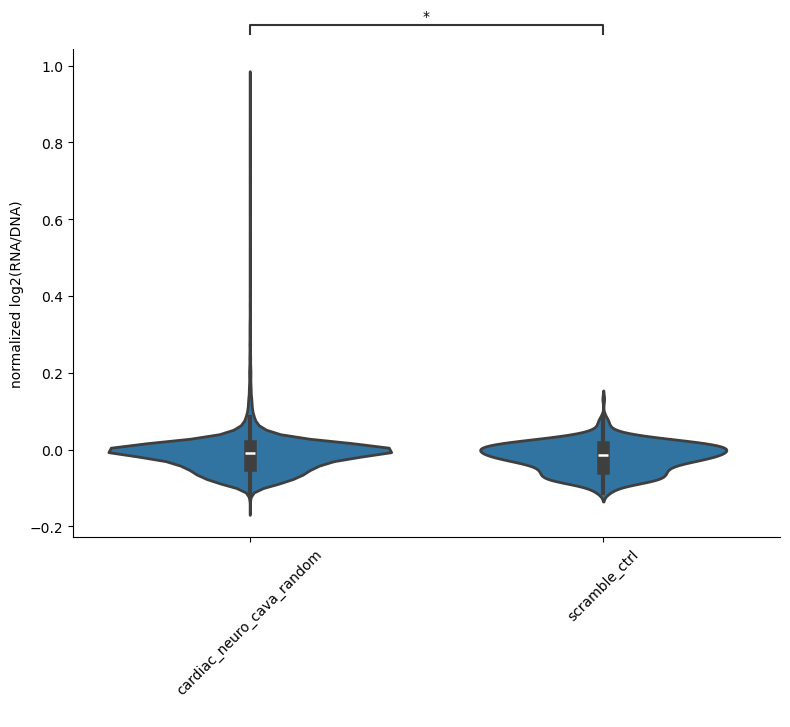

In [39]:
# plot a violin plot for each label
from statannotations.Annotator import Annotator
import matplotlib.pyplot as plt
import seaborn as sns
y_axis_col = "not_shifted_bcalm_element_log_ratio_activity"
x_axis_col = "label"
fig, ax = plt.subplots(figsize=(8,6))

# violin plot with inner boxplot width 4, color of line same as violinplot of that label, color liveMPRA_(+) and DNase_(+) same, liverMPRA_(-) and DNase_(-) same and test cCREs different
sns.violinplot(x=x_axis_col, y=y_axis_col, data=mpra_80k_metadata_df_filtered, ax=ax, inner='box', linewidth=2)
annotator = Annotator(ax, pairs=[('cardiac_neuro_cava_random', 'scramble_ctrl')], data=mpra_80k_metadata_df_filtered, x=x_axis_col, y=y_axis_col)
annotator.configure(test="Mann-Whitney", loc="outside", verbose=2)
annotator.apply_and_annotate()

# axis labels
ax.set_xlabel(' ')
ax.set_ylabel('normalized log2(RNA/DNA)')
plt.tight_layout()

# rotate x axis labels
plt.xticks(rotation=45)

# remove the top and right spines from plot
sns.despine()

plt.show()

<Axes: >

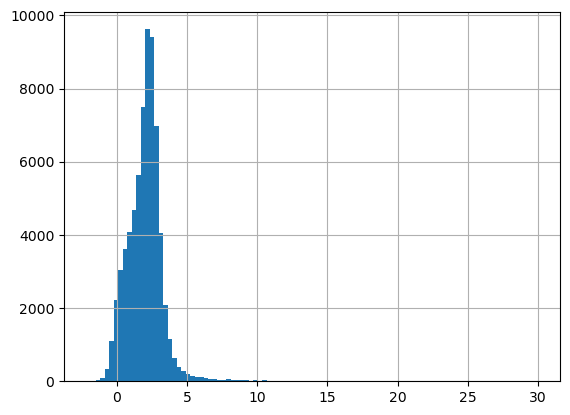

In [10]:
mpra_80k_metadata_df_tested_bcalm['bcalm_element_log_ratio_activity_z_score_neg_ctrl'].hist(bins=100)


<Axes: >

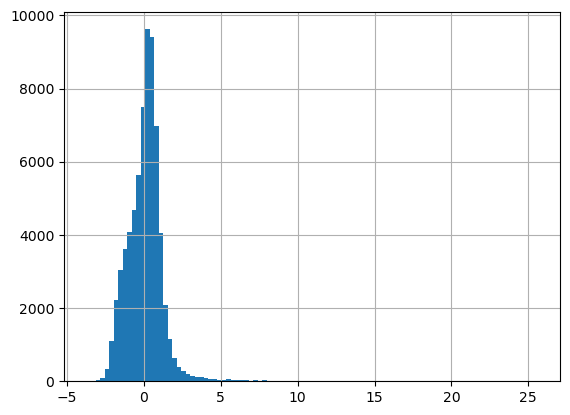

In [12]:
mpra_80k_metadata_df_tested_bcalm['bcalm_element_log_ratio_activity_z_score_scrambled_ctrl'].hist(bins=100)

<Axes: >

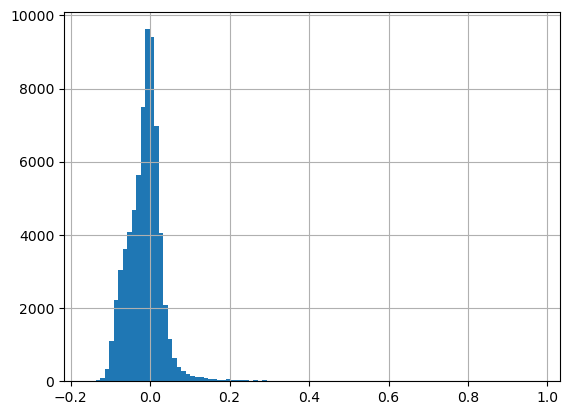

In [13]:
mpra_80k_metadata_df_tested_bcalm['bcalm_element_log_ratio_activity'].hist(bins=100)

In [38]:
mpra_80k_metadata_df_tested_bcalm.head()
mpra_80k_metadata_df_tested_bcalm['start'] = mpra_80k_metadata_df_tested_bcalm['start'].astype(int)
mpra_80k_metadata_df_tested_bcalm['end'] = mpra_80k_metadata_df_tested_bcalm['end'].astype(int)

In [ ]:
mpra_80k_metadata_df_tested_bcalm
# output_path = "/home/kisa/coding/80K_MPRA/element_analysis_output/202502_element_analysis/NGN2_bcalm_element_activity_group_2025_04_bbmap_normalized_counts_log2_zscore_scrambled_ctrl_log2_zscore_neuro_ctrl_activity_groups.tsv.gz"
# output_path = "/home/kisa/coding/80K_MPRA/element_analysis_output/202502_element_analysis/undiffWTC11_bcalm_element_activity_group_2025_04_bbmap_normalized_counts_log2_zscore_scrambled_ctrl_log2_zscore_neuro_ctrl_activity_groups.tsv.gz"
# write as table
# mpra_80k_metadata_df_tested_bcalm.to_csv(output_path, sep="\t", index=False)

In [ ]:
# # load the data on the charite hpc
# mpra_80k_metadata_hpc_data_path = "/home/kisa11/work/projects/80K_MPRA/learn_from_sequence/NGN2_bcalm_element_activity_group_2025_04_bbmap_normalized_counts_log2_zscore_neuro_ctrl.tsv.gz"
# mpra_80k_metadata_hpc_data_path = "/home/kisa/coding/80K_MPRA/element_analysis_output/202502_element_analysis/undiffWTC11_bcalm_element_activity_group_2025_04_bbmap_normalized_counts_log2_zscore_scrambled_ctrl_log2_zscore_neuro_ctrl_activity_groups.tsv.gz"
# mpra_80k_metadata_hpc_data_path = "/home/kisa/coding/80K_MPRA/element_analysis_output/202502_element_analysis/undiffWTC11_bcalm_element_activity_group_2025_04_bbmap_normalized_counts_log2_zscore_scrambled_ctrl_log2_zscore_neuro_ctrl_activity_groups.tsv.gz"

# mpra_80k_metadata_df_tested_bcalm = pd.read_csv(mpra_80k_metadata_hpc_data_path, sep="\t", low_memory=False)

# # use safe eval on list
# # Apply the safe_eval function to the specified columns
# for col in list_columns:
#     mpra_80k_metadata_df_tested_bcalm[col] = mpra_80k_metadata_df_tested_bcalm[col].apply(safe_eval)




#### Plot the distribution of the activity of the group values and the group distribution

In [14]:
mpra_80k_metadata_df_tested_bcalm['activity_group'].value_counts()

activity_group
no_activity                56836
negative_control_active     7128
high_active                 2530
scramble_less_active        1747
Name: count, dtype: int64

In [15]:
def get_activity_group_name(activity_group):
    if activity_group == "no_activity":
        return "no significant activity"
    if activity_group == "negative_control_active":
        return "regulatory active"
    if activity_group == "high_active":
        return "high active"
    if activity_group == "scramble_less_active":
        return "negative regulatory activity"

def get_activity_group_name_pie_chart(activity_group):
    if activity_group == "no_activity":
        return "no significant activity"
    if activity_group == "negative_control_active":
        return "more active than negative ctrl"
    if activity_group == "high_active":
        return "more active than scrambled"
    if activity_group == "scramble_less_active":
        return "negative regulatory activity"

In [16]:
mpra_80k_metadata_df_tested_bcalm["plot_activity_group"] = mpra_80k_metadata_df_tested_bcalm["activity_group"].apply(get_activity_group_name)

In [17]:
mpra_80k_metadata_df_tested_bcalm["plot_activity_group"].value_counts()

plot_activity_group
no significant activity         56836
regulatory active                7128
high active                      2530
negative regulatory activity     1747
Name: count, dtype: int64

In [18]:
mpra_80k_metadata_df_tested_bcalm_sorted = mpra_80k_metadata_df_tested_bcalm.sort_values(by=logFC_column, ascending=False)

In [19]:
mpra_80k_metadata_df_tested_bcalm_sorted.columns

Index(['name', 'sequence', 'category', 'class', 'source', 'ref', 'chr',
       'start', 'end', 'strand', 'variant_class', 'variant_pos', 'SPDI',
       'allele', 'info', 'bcalm_element_adjusted_p_value',
       'bcalm_element_log_ratio_activity', 'bcalm_data_exists', 'label',
       'not_shifted_bcalm_element_log_ratio_activity',
       'bcalm_element_log_ratio_activity_z_score_neg_ctrl',
       'bcalm_element_log_ratio_activity_z_score_scrambled_ctrl',
       'activity_group', 'activity_group_numeric', 'plot_activity_group'],
      dtype='object')

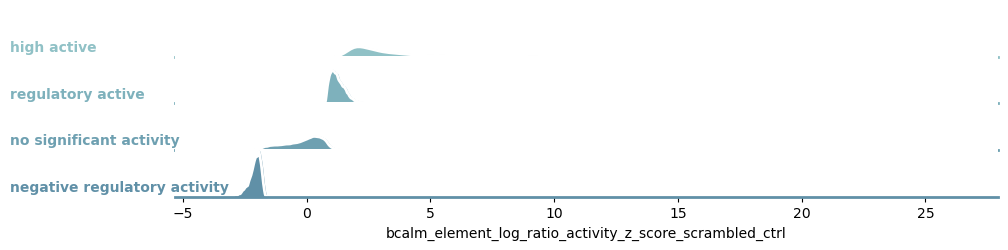

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plot_name_col = "plot_activity_group"
plot_value_col = "bcalm_element_log_ratio_activity"
plot_value_col = "bcalm_element_log_ratio_activity_z_score_neg_ctrl"
plot_value_col = "bcalm_element_log_ratio_activity_z_score_scramble_ctrl"
plot_value_col = "bcalm_element_log_ratio_activity_z_score_scrambled_ctrl"

# Initialize the FacetGrid object
pal = sns.cubehelix_palette(10, rot=-.25, light=.7)
g = sns.FacetGrid(mpra_80k_metadata_df_tested_bcalm_sorted, row=plot_name_col, hue=plot_name_col, aspect=15, height=.7, palette=pal)

# Draw the densities in a few steps
g.map(sns.kdeplot, plot_value_col,
      bw_adjust=.5, clip_on=False,
      fill=True, alpha=1, linewidth=1.5)
g.map(sns.kdeplot, plot_value_col, clip_on=False, color="w", lw=2, bw_adjust=.5)

# passing color=None to refline() uses the hue mapping
g.refline(y=0, linewidth=2, linestyle="-", color=None, clip_on=False)


# Define and use a simple function to label the plot in axes coordinates
def label(x, color, label):
      ax = plt.gca()
      ax.text(-0.2, .2, label, fontweight="bold", color=color, ha="left", va="center", transform=ax.transAxes)


g.map(label, plot_value_col)

# Set the subplots to overlap
g.figure.subplots_adjust(hspace=-0.02)

# Remove axes details that don't play well with overlap
g.set_titles("")
g.set(yticks=[], ylabel="")
g.despine(bottom=True, left=True)
# plt.title("Activity of sequences in NGN2 derived neurons from WTC11")

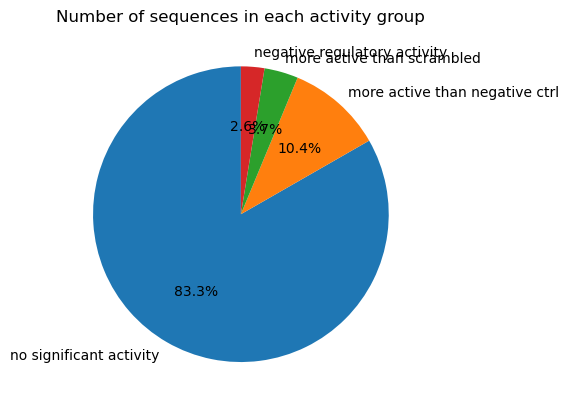

In [22]:
# Get counts
mpra_80k_metadata_df_tested_bcalm["plot_pie_chart_activity_group"] = mpra_80k_metadata_df_tested_bcalm["activity_group"].apply(get_activity_group_name_pie_chart)

counts = mpra_80k_metadata_df_tested_bcalm["plot_pie_chart_activity_group"].value_counts()

# Plot pie chart
counts.plot.pie(autopct='%1.1f%%', startangle=90, ylabel='')
plt.title('Number of sequences in each activity group')
plt.show()

Text(0.5, 1.0, 'tested cCRE activity distribution within NGN2 induced WTC11 neurons')

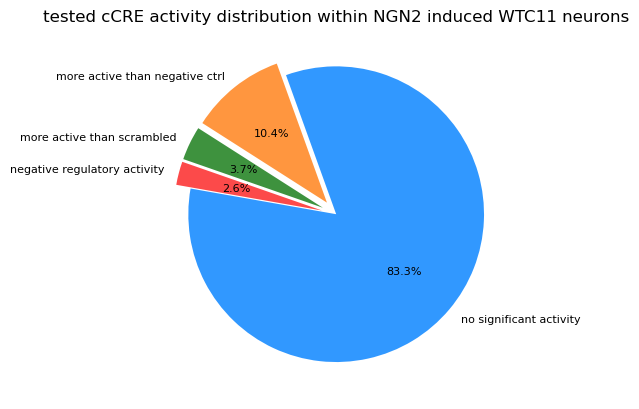

In [25]:
counts = mpra_80k_metadata_df_tested_bcalm["plot_pie_chart_activity_group"].value_counts()

# color palette
colors = {
    "no significant activity": "#3198FF",  # blue
    "more active than negative ctrl": "#FF963F",  # orange
    "negative regulatory activity": "#FC4A4A",  # red
    "more active than scrambled": "#3E923E",  # Blue
}

explode = [0.1 if val < counts.max() else 0 for val in counts]  # Explode everything except the biggest
counts.plot.pie(
    autopct='%1.1f%%',
    startangle=170,
    ylabel='',
    textprops={'fontsize': 8},
    explode=explode,
    colors=[colors[val] for val in counts.index],
)
plt.title("tested cCRE activity distribution within NGN2 induced WTC11 neurons")

Text(0.5, 1.0, 'tested cCRE activity distribution within NGN2 induced WTC11 neurons')

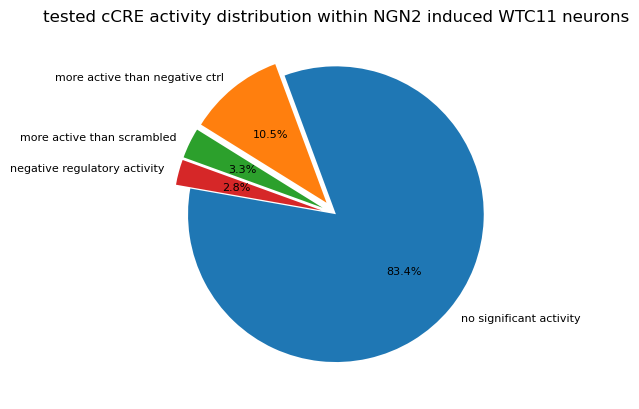

In [24]:
mpra_80k_metadata_df_tested_bcalm_only_regions = mpra_80k_metadata_df_tested_bcalm.loc[~mpra_80k_metadata_df_tested_bcalm['name'].str.contains("cardiac_neuro_cava_random:ALT_")].copy()

counts = mpra_80k_metadata_df_tested_bcalm_only_regions["plot_pie_chart_activity_group"].value_counts()

explode = [0.1 if val < counts.max() else 0 for val in counts]  # Explode everything except the biggest
counts.plot.pie(
    autopct='%1.1f%%',
    startangle=170,
    ylabel='',
    textprops={'fontsize': 8},
    explode=explode
)
plt.title("tested cCRE activity distribution within NGN2 induced WTC11 neurons")

In [28]:
mpra_80k_metadata_df_tested_bcalm.columns

Index(['name', 'sequence', 'category', 'class', 'source', 'ref', 'chr',
       'start', 'end', 'strand', 'variant_class', 'variant_pos', 'SPDI',
       'allele', 'info', 'bcalm_element_adjusted_p_value',
       'bcalm_element_log_ratio_activity', 'bcalm_data_exists', 'label',
       'not_shifted_bcalm_element_log_ratio_activity',
       'bcalm_element_log_ratio_activity_z_score_neg_ctrl',
       'bcalm_element_log_ratio_activity_z_score_scrambled_ctrl',
       'activity_group', 'activity_group_numeric', 'plot_activity_group',
       'plot_pie_chart_activity_group'],
      dtype='object')

In [ ]:
mpra_80k_metadata_df_tested_bcalm

ValueError: Missing value(s) ['scramble_ctrl'] for label (specified in `pairs`) in data.

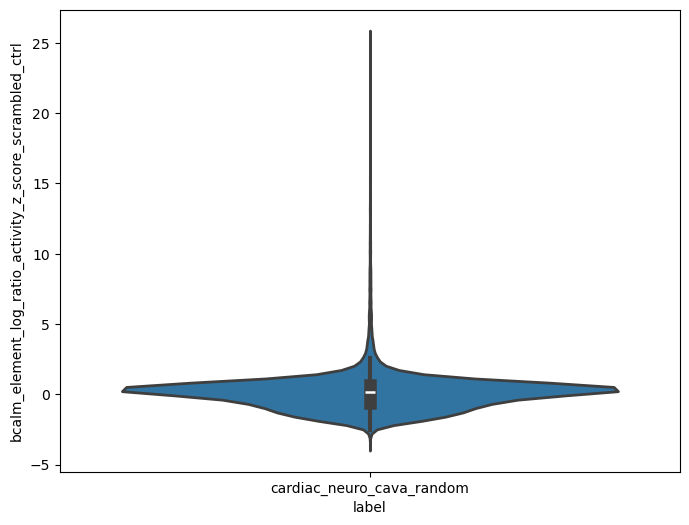

In [76]:
counts

plot_pie_chart_activity_group
no significant activity           65052
more active than negative ctrl     1962
more active than scrambled          444
negative regulatory activity         48
Name: count, dtype: int64

Text(0.5, 1.0, 'tested cCRE activity distribution within undifferentiated WTC11')

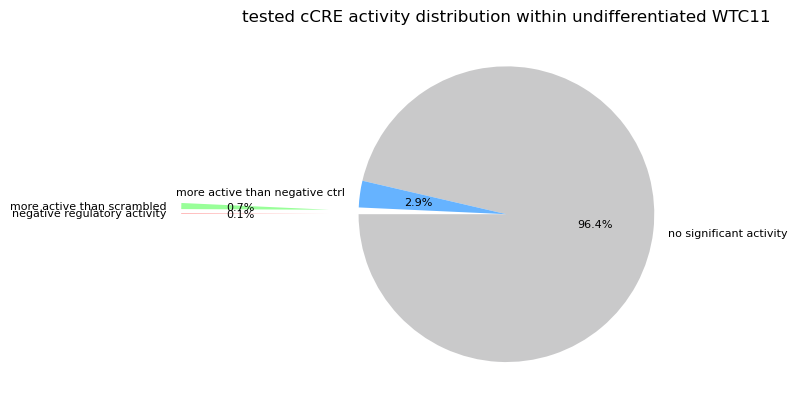

In [74]:
counts = mpra_80k_metadata_df_tested_bcalm["plot_pie_chart_activity_group"].value_counts()

colors = ['#ffcc99','#66b3ff','#99ff99', '#ff9999']  # Adjust for your group count
colors = ['#c9c9ca','#66b3ff','#99ff99', '#ff9999']  # Adjust for your group count
explode = [1.2 if val < 500 else 0 for val in counts]  # Explode everything except the biggest
counts.plot.pie(
    autopct='%1.1f%%',
    startangle=180,
    ylabel='',
    textprops={'fontsize': 8},
    explode=explode,
    colors=colors,
)
plt.title("tested cCRE activity distribution within undifferentiated WTC11")

In [83]:
counts

plot_pie_chart_activity_group
no significant activity           65052
more active than negative ctrl     1962
more active than scrambled          444
negative regulatory activity         48
Name: count, dtype: int64

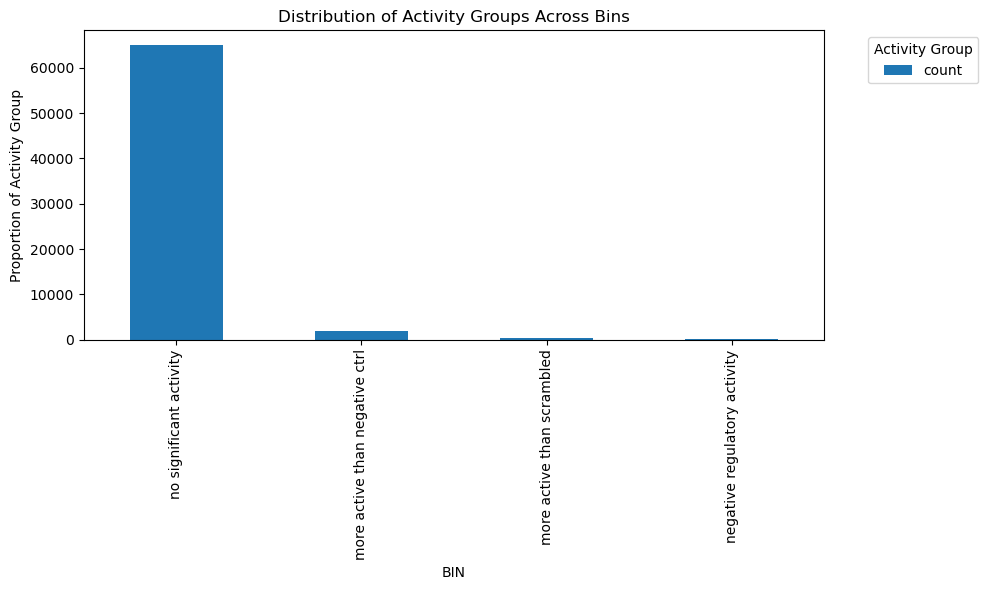

In [ ]:
counts = mpra_80k_metadata_df_tested_bcalm["plot_pie_chart_activity_group"].value_counts()

# # Step 2: Normalize to get proportions (optional, comment this out if you want raw counts)
# proportions = counts.div(counts.sum(axis=1), axis=0)

# Step 3: Plot as stacked bar plot
counts.plot(kind='bar', stacked=True, colormap='tab10', figsize=(10, 6))

# Optional formatting
plt.ylabel('Proportion of Activity Group')
plt.xlabel('activity group')
plt.title('Distribution of Activity Groups Across Bins')
plt.legend(title='Activity Group', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

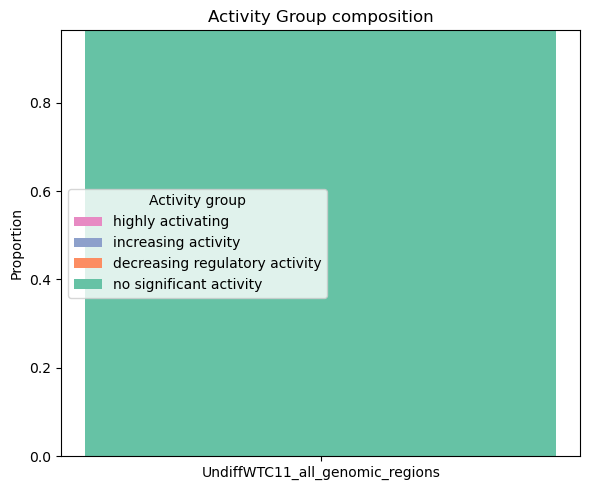

In [85]:
# plot: with no significant elements

# Compute normalized value counts
# counts1 = mpra_80k_metadata_df_tested_bcalm_REF['plot_activity_group'].value_counts(normalize=True)
# counts2 = mpra_80k_metadata_df_tested_bcalm_open_NGN2_wtc11_atac_REF['plot_activity_group'].value_counts(normalize=True)
# counts2 = mpra_80k_metadata_df_tested_bcalm_neuro_CRE_REF['plot_activity_group'].value_counts(normalize=True)
counts3 = mpra_80k_metadata_df_tested_bcalm['plot_activity_group'].value_counts(normalize=True)

# Combine into one DataFrame
# combined = pd.DataFrame({'All_genomic_regions': counts1, 'NGN2_WTC11_open_genomic_regions': counts2}).fillna(0)
combined = pd.DataFrame({'UndiffWTC11_all_genomic_regions': counts3}).fillna(0)



# Reorder for consistent stacking
desired_order = ['no significant activity', 'decreasing regulatory activity',
       'increasing activity', 'highly activating']
combined = combined.reindex(desired_order)
# Define a consistent color palette
group_colors = dict(zip(combined.index, sns.color_palette("Set2", n_colors=len(combined))))

# Plot
fig, ax = plt.subplots(figsize=(6, 5))
bottoms = {'All_genomic_regions': 0, 'NGN2_WTC11_open_genomic_regions': 0, 'UndiffWTC11_all_genomic_regions': 0}

for group in combined.index:
    # ax.bar('All_genomic_regions', combined.loc[group, 'All_genomic_regions'], bottom=bottoms['All_genomic_regions'], color=group_colors[group], label=group)
    # ax.bar('NGN2_WTC11_open_genomic_regions', combined.loc[group, 'NGN2_WTC11_open_genomic_regions'], bottom=bottoms['NGN2_WTC11_open_genomic_regions'], color=group_colors[group])
    # bottoms['All_genomic_regions'] += combined.loc[group, 'All_genomic_regions']
    # bottoms['NGN2_WTC11_open_genomic_regions'] += combined.loc[group, 'NGN2_WTC11_open_genomic_regions']
    ax.bar('UndiffWTC11_all_genomic_regions', combined.loc[group, 'UndiffWTC11_all_genomic_regions'], bottom=bottoms['UndiffWTC11_all_genomic_regions'], color=group_colors[group], label=group)
    bottoms['UndiffWTC11_all_genomic_regions'] += combined.loc[group, 'UndiffWTC11_all_genomic_regions']

# # Only show one legend entry per group
# handles, labels = ax.get_legend_handles_labels()
# by_label = dict(zip(labels, handles))
# ax.legend(by_label.values(), by_label.keys(), title="Activity group")


handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))

# Reverse the order
reversed_labels = list(by_label.keys())[::-1]
reversed_handles = [by_label[label] for label in reversed_labels]

ax.legend(reversed_handles,
          reversed_labels,
          title="Activity group",
          loc='center left',
          )


ax.set_ylabel("Proportion")
ax.set_title("Activity Group composition")
plt.tight_layout()
plt.show()

In [40]:
mpra_80k_metadata_df_tested_bcalm_ALT = mpra_80k_metadata_df_tested_bcalm.loc[mpra_80k_metadata_df_tested_bcalm['name'].str.contains(":ALT_")].copy()
mpra_80k_metadata_df_tested_bcalm_REF = mpra_80k_metadata_df_tested_bcalm.loc[~mpra_80k_metadata_df_tested_bcalm['name'].str.contains(":ALT_")].copy()


In [ ]:
# plot: without no significant elements
mpra_80k_metadata_df_tested_bcalm_REF_filtered = mpra_80k_metadata_df_tested_bcalm_REF.loc[mpra_80k_metadata_df_tested_bcalm_REF['activity_group'] != "no_activity"].copy()
mpra_80k_metadata_df_tested_bcalm_open_NGN2_wtc11_atac_REF_filtered = mpra_80k_metadata_df_tested_bcalm_open_NGN2_wtc11_atac_REF.loc[mpra_80k_metadata_df_tested_bcalm_open_NGN2_wtc11_atac_REF['activity_group'] != "no_activity"].copy()
mpra_80k_metadata_df_tested_bcalm_neuro_CRE_REF_filtered = mpra_80k_metadata_df_tested_bcalm_neuro_CRE_REF.loc[mpra_80k_metadata_df_tested_bcalm_neuro_CRE_REF['activity_group'] != "no_activity"].copy()
# Compute normalized value counts
counts1 = mpra_80k_metadata_df_tested_bcalm_REF_filtered['plot_activity_group'].value_counts(normalize=True)
counts2 = mpra_80k_metadata_df_tested_bcalm_open_NGN2_wtc11_atac_REF_filtered['plot_activity_group'].value_counts(normalize=True)
counts2 = mpra_80k_metadata_df_tested_bcalm_neuro_CRE_REF_filtered['plot_activity_group'].value_counts(normalize=True)

# Combine into one DataFrame
combined = pd.DataFrame({'All_genomic_regions': counts1, 'NGN2_WTC11_open_genomic_regions': counts2}).fillna(0)

# Reorder for consistent stacking
desired_order = ['decreasing regulatory activity',
       'increasing activity', 'highly activating']
combined = combined.reindex(desired_order)
# Define a consistent color palette
group_colors = dict(zip(combined.index, sns.color_palette("Set2", n_colors=len(combined))))

# Plot
fig, ax = plt.subplots(figsize=(6, 5))
bottoms = {'All_genomic_regions': 0, 'NGN2_WTC11_open_genomic_regions': 0}

for group in combined.index:
    ax.bar('All_genomic_regions', combined.loc[group, 'All_genomic_regions'], bottom=bottoms['All_genomic_regions'], color=group_colors[group], label=group)
    ax.bar('NGN2_WTC11_open_genomic_regions', combined.loc[group, 'NGN2_WTC11_open_genomic_regions'], bottom=bottoms['NGN2_WTC11_open_genomic_regions'], color=group_colors[group])
    bottoms['All_genomic_regions'] += combined.loc[group, 'All_genomic_regions']
    bottoms['NGN2_WTC11_open_genomic_regions'] += combined.loc[group, 'NGN2_WTC11_open_genomic_regions']

# # Only show one legend entry per group
# handles, labels = ax.get_legend_handles_labels()
# by_label = dict(zip(labels, handles))
# ax.legend(by_label.values(), by_label.keys(), title="Activity group")


handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))

# Reverse the order
reversed_labels = list(by_label.keys())[::-1]
reversed_handles = [by_label[label] for label in reversed_labels]

ax.legend(reversed_handles,
          reversed_labels,
          title="Activity group",
          loc='center left',
          )


ax.set_ylabel("Proportion")
ax.set_title("Activity Group composition")
plt.tight_layout()
plt.show()

#### Resample (only 8000 no activity sequences)

In [25]:
# Step 1: Separate the dominant group
dominant_group = mpra_80k_metadata_df_tested_bcalm[mpra_80k_metadata_df_tested_bcalm["activity_group"] == "no_activity"]

# Step 2: Subsample it to 8k
dominant_group_subsampled = dominant_group.sample(n=8000, random_state=42)

# Step 3: Keep all other groups as is
other_groups = mpra_80k_metadata_df_tested_bcalm[mpra_80k_metadata_df_tested_bcalm["activity_group"] != "no_activity"]

# Step 4: Combine them
balanced_df = pd.concat([dominant_group_subsampled, other_groups], ignore_index=True)

# Optional: Shuffle the resulting DataFrame
balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

In [26]:
balanced_df

,name,sequence,category,class,source,ref,chr,start,end,strand,...,bcalm_element_log_ratio_activity,bcalm_data_exists,label,not_shifted_bcalm_element_log_ratio_activity,bcalm_element_log_ratio_activity_z_score_neg_ctrl,bcalm_element_log_ratio_activity_z_score_scrambled_ctrl,activity_group,activity_group_numeric,bcalm_element_log_ratio_activity_z_score_scramble_ctrl,BIN
0,cardiac_neuro_cava_random:PARS2|ENSG0000016239...,ATAGCCAAGCTCCCCAACATTTCCTTCTTTTGGGGCCATCTTTTGA...,element,test,NaN,GRCh38,chr1,54794147,54794417,-,...,-0.048801,True,cardiac_neuro_cava_random,-0.048801,0.982835,-0.870203,no_activity,1,-0.870203,1
1,cardiac_neuro_cava_random:ALT_CTNNA3|ENSG00000...,TATATACTCATTTAAAAGATTAGGTTAATCATTAGTGCTGTCTATC...,variant,test,NaN,GRCh38,chr10,66547043,66547313,-,...,0.110130,True,cardiac_neuro_cava_random,0.110130,5.482559,3.239802,high_active,3,3.239802,7
2,cardiac_neuro_cava_random:ALT_TSHZ3|ENSG000001...,CCAGCTCCCAGGGCACTGGCAGGGGCTCTGTGTTCCCCAGGTCCAG...,variant,test,NaN,GRCh38,chr19,31386892,31387162,-,...,-0.052472,True,cardiac_neuro_cava_random,-0.052472,0.878892,-0.965143,no_activity,1,-0.965143,6
3,cardiac_neuro_cava_random:MEIS2|ENSG0000013413...,TGGGAAGGTCAAGAATAGTTCACAAGGATGAGCCGATGTTTATGGA...,element,test,NaN,GRCh38,chr15,37105905,37106175,-,...,0.040394,True,cardiac_neuro_cava_random,0.040394,3.508154,1.436399,negative_control_active,2,1.436399,9
4,cardiac_neuro_cava_random:ALT_ZBTB20|ENSG00000...,TTTCTAAGCTGAAGAATGTTTCTGCACTGCATGGAGCTCAAATACA...,variant,test,NaN,GRCh38,chr3,114858409,114858679,-,...,0.023271,True,cardiac_neuro_cava_random,0.023271,3.023361,0.993594,negative_control_active,2,0.993594,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19400,cardiac_neuro_cava_random:REF_FOXP1|ENSG000001...,TCTTTGATAAAGTCTTTGTTCCATATTGACACAAGCTTCTTATAAT...,variant,test,NaN,GRCh38,chr3,71188997,71189267,-,...,0.032122,True,cardiac_neuro_cava_random,0.032122,3.273952,1.222482,negative_control_active,2,1.222482,2
19401,cardiac_neuro_cava_random:REF_RHOBTB2|ENSG0000...,GAATTTCGATCTTTTCCTGGGCTAGCAGTATGTGGTAGGATACTGC...,variant,test,NaN,GRCh38,chr8,22949557,22949827,+,...,0.041348,True,cardiac_neuro_cava_random,0.041348,3.535162,1.461069,negative_control_active,2,1.461069,7
19402,cardiac_neuro_cava_random:ALT_IGLV3-25|ENSG000...,CTGTTAAAGGCAACAACATAGGTTAGTATAAAAGGCAGCATTATGG...,variant,test,NaN,GRCh38,chr22,22658628,22658898,+,...,-0.041737,True,cardiac_neuro_cava_random,-0.041737,1.182844,-0.687517,no_activity,1,-0.687517,4
19403,cardiac_neuro_cava_random:ALT_ZNF462|ENSG00000...,GGCCATGGTCTGTGGCCAGGGGAATTTAGGGTCAAGGGTTGGTTTA...,variant,test,NaN,GRCh38,chr9,106933584,106933854,+,...,-0.010698,True,cardiac_neuro_cava_random,-0.010698,2.061622,0.115151,no_activity,1,0.115151,9


#### Balancing of the data: 

In [16]:
# functions for the binning of the data
import re
import numpy as np

def extract_genes(name):
    # Updated regex pattern to match gene names
    pattern = r'(?:REF_|ALT_)?([A-Z0-9-]+)(?=\|ENSG)'

    # Find all matches
    matches = re.findall(pattern, name)

    # Return a set of unique gene names
    return list(set(matches))


def balanced_chromosome_bins(df, n_bins=10, random_state=42):
    # Step 1: Count sequences per chromosome
    chr_counts = df['chr'].value_counts().reset_index()
    chr_counts.columns = ['chr', 'count']

    # Step 2: Sort chromosomes by size (largest first)
    chr_counts = chr_counts.sort_values(by='count', ascending=False).reset_index(drop=True)

    # Step 3: Initialize bins and their size trackers
    bins = [[] for _ in range(n_bins)]
    bin_sizes = np.zeros(n_bins)  # Track total sequence counts per bin

    # Step 4: Distribute chromosomes using "First-Fit Decreasing" heuristic
    for _, row in chr_counts.iterrows():
        smallest_bin = np.argmin(bin_sizes)  # Find the least filled bin
        bins[smallest_bin].append(row['chr'])
        bin_sizes[smallest_bin] += row['count']  # Update bin size

    # Step 5: Create a mapping dictionary
    group_to_bin = {chr_name: bin_idx+1 for bin_idx, bin_groups in enumerate(bins) for chr_name in bin_groups}

    # Step 6: Map chromosomes to bins in the original DataFrame
    df['BIN'] = df['chr'].map(group_to_bin)

    return df

In [78]:
mpra_80k_metadata_df_tested_bcalm_without_no_activity = mpra_80k_metadata_df_tested_bcalm.loc[mpra_80k_metadata_df_tested_bcalm['activity_group'] != "no_activity"].copy()

In [27]:
# get tested bcalm data
mpra_80k_metadata_df_chr_binning = balanced_chromosome_bins(mpra_80k_metadata_df_tested_bcalm)
# mpra_80k_metadata_df_without_no_activity_chr_binning = balanced_chromosome_bins(mpra_80k_metadata_df_tested_bcalm_without_no_activity)
mpra_80k_ngn2_balanced_chr_binning = balanced_chromosome_bins(balanced_df)

In [20]:
mpra_80k_metadata_df_chr_binning

,name,sequence,category,class,source,ref,chr,start,end,strand,...,bcalm_element_log_ratio_activity,bcalm_data_exists,label,not_shifted_bcalm_element_log_ratio_activity,bcalm_element_log_ratio_activity_z_score_neg_ctrl,bcalm_element_log_ratio_activity_z_score_scrambled_ctrl,activity_group,activity_group_numeric,bcalm_element_log_ratio_activity_z_score_scramble_ctrl,BIN
2287,cardiac_neuro_cava_random:SKI|ENSG00000157933....,AAGAATACAAGTAACTGATGAATGAAGGGGGCATCTTGTGTCCCCA...,element,test,NaN,GRCh38,chr1,2181843,2182113,+,...,-0.074506,True,cardiac_neuro_cava_random,-0.074506,0.255056,-1.534950,no_activity,1,-1.534950,1
2288,cardiac_neuro_cava_random:SKI|ENSG00000157933....,TTGGGTATGCTGCCCCCCAGCTGGCGGGGCACCGGGGACAGGCACA...,element,test,NaN,GRCh38,chr1,2182439,2182709,+,...,0.024747,True,cardiac_neuro_cava_random,0.024747,3.065142,1.031757,no_activity,1,1.031757,1
2289,cardiac_neuro_cava_random:SKI|ENSG00000157933....,ACGAGCAAGGGAATGAGAGAGAGTGGGTTAGAGAGTGAGTGAGCCA...,element,test,NaN,GRCh38,chr1,2182830,2183100,+,...,0.058800,True,cardiac_neuro_cava_random,0.058800,4.029274,1.912386,no_activity,1,1.912386,1
2290,cardiac_neuro_cava_random:SKI|ENSG00000157933....,CGTGGACACGCGTGATTGACCCTTTAACTGTATCCTTAACCACCGC...,element,test,NaN,GRCh38,chr1,2185027,2185297,+,...,-0.071544,True,cardiac_neuro_cava_random,-0.071544,0.338923,-1.458346,no_activity,1,-1.458346,1
2291,cardiac_neuro_cava_random:SKI|ENSG00000157933....,CCGGAGAGTCTCAGCTCCCGCAGCCCTAACAAACGACCACAGACCT...,element,test,NaN,GRCh38,chr1,2188389,2188659,+,...,-0.044408,True,cardiac_neuro_cava_random,-0.044408,1.107215,-0.756596,no_activity,1,-0.756596,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76222,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,GGAGCTCTGCCTCACCCCACCTGGCCCCAATTGTCCAGCTTGTAGA...,variant,test,NaN,GRCh38,chrX,154545000,154545270,-,...,0.065547,True,cardiac_neuro_cava_random,0.065547,4.220287,2.086855,negative_control_active,2,2.086855,6
76223,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,ATGTCTGAATTCACCTCCAAATAATGGGAAAACTCCTAGGTATATA...,variant,test,NaN,GRCh38,chrX,154549802,154550072,-,...,-0.090558,True,cardiac_neuro_cava_random,-0.090558,-0.199415,-1.950059,scramble_less_active,0,-1.950059,6
76224,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCCC...,variant,test,NaN,GRCh38,chrX,154552145,154552415,-,...,0.052674,True,cardiac_neuro_cava_random,0.052674,3.855845,1.753977,negative_control_active,2,1.753977,6
76225,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCTC...,variant,test,NaN,GRCh38,chrX,154552145,154552415,-,...,0.016824,True,cardiac_neuro_cava_random,0.016824,2.840822,0.826865,no_activity,1,0.826865,6


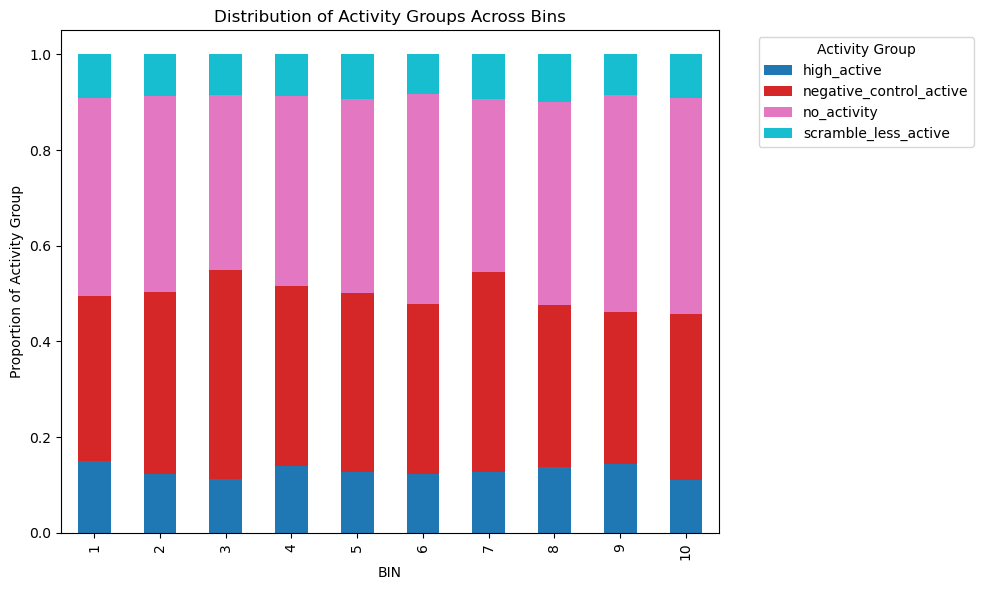

In [28]:
import matplotlib.pyplot as plt
# show that the bin and activity group distribution is fine
# Step 1: Create a counts table
counts = mpra_80k_metadata_df_chr_binning.groupby(['BIN', 'activity_group']).size().unstack(fill_value=0)
counts = mpra_80k_ngn2_balanced_chr_binning.groupby(['BIN', 'activity_group']).size().unstack(fill_value=0)

# Step 2: Normalize to get proportions (optional, comment this out if you want raw counts)
proportions = counts.div(counts.sum(axis=1), axis=0)

# Step 3: Plot as stacked bar plot
proportions.plot(kind='bar', stacked=True, colormap='tab10', figsize=(10, 6))

# Optional formatting
plt.ylabel('Proportion of Activity Group')
plt.xlabel('BIN')
plt.title('Distribution of Activity Groups Across Bins')
plt.legend(title='Activity Group', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [29]:
# write unbalanced and balanced data to a file as data for neural networks
output_path_data_binning = "/home/kisa/coding/80K_MPRA/element_analysis_output/202502_element_analysis/original_NGN2_chr_binning_bcalm_element_activity_group_2025_04_bbmap_normalized_counts_log2_zscore_scrambled_ctrl_log2_zscore_neuro_ctrl.tsv.gz"
output_path_data_binning_balanced = "/home/kisa/coding/80K_MPRA/element_analysis_output/202502_element_analysis/balanced_NGN2_chr_binning_bcalm_element_activity_group_2025_04_bbmap_normalized_counts_log2_zscore_scrambled_ctrl_log2_zscore_neuro_ctrl.tsv.gz"
writing = False
if writing:
    # write as table
    mpra_80k_metadata_df_chr_binning.to_csv(output_path_data_binning, sep="\t", index=False)
    mpra_80k_ngn2_balanced_chr_binning.to_csv(output_path_data_binning_balanced, sep="\t", index=False)

In [ ]:
mpra_80k_metadata_df_chr_binning.shape[0]

68241

In [69]:
mpra_80k_ngn2_balanced_chr_binning.shape[0]

19165

In [47]:
mpra_80k_metadata_df_no_activity_chr_binning.shape[0]

57162

In [ ]:
mpra_80k_metadata_df_no_activity_chr_binning['BIN'].value_counts()


BIN
1     6686
10    6409
8     6321
7     5602
9     5539
2     5497
4     5411
3     5336
5     5196
6     5165
Name: count, dtype: int64

In [80]:
mpra_80k_ngn2_balanced_chr_binning['BIN'].value_counts()

BIN
1     2197
9     2062
8     2030
4     1856
3     1851
10    1838
6     1825
2     1825
7     1716
5     1712
Name: count, dtype: int64

In [ ]:
# normalize the logFC

In [70]:
# train test split and store the respective files:
def write_train_test_fasta(df, test_output_fasta, train_output_fasta, test_output_y, train_output_y, test_bins, bin_col="BIN", y_col="bcalm_element_log_ratio_activity"):
    # get test train split
    df_test = df.loc[df[bin_col].isin(test_bins)]
    df_train = df.loc[~df[bin_col].isin(test_bins)]
    # write sequences
    hf.write_fasta(df_test, test_output_fasta, header=["name", "sequence"])
    hf.write_fasta(df_train, train_output_fasta, header=["name", "sequence"])
    # write y output
    df_test[[y_col]].to_csv(test_output_y, sep="\t", index=False, header=None)
    df_train[[y_col]].to_csv(train_output_y, sep="\t", index=False, header=None)
    return df_test, df_test[[y_col]], df_train, df_train[[y_col]]


In [ ]:
mpra_80k_metadata_df_chr_binning['BIN'].value_counts()
# split in test and training set
mpra_80k_metadata_df_chr_binning_test = mpra_80k_metadata_df_chr_binning.loc[mpra_80k_metadata_df_chr_binning['BIN'].isin([1, 9])]
mpra_80k_metadata_df_chr_binning_training = mpra_80k_metadata_df_chr_binning.loc[~mpra_80k_metadata_df_chr_binning['BIN'].isin([1, 9])]
# fasta of sequences
test_fasta_output = "/home/kisa/coding/80K_MPRA/80K-Analysis/06_variant_element_analysis/notebooks/rlsgkm/src/gkm_svm_test.fa"
test_fasta_output = "/home/kisa/coding/80K_MPRA/80K-Analysis/06_variant_element_analysis/notebooks/rlsgkm/src/gkm_svm_test.fa"
hf.write_fasta(mpra_80k_metadata_df_chr_binning_test, test_fasta_output, header=['name', 'sequence'])
training_fasta_output = "/home/kisa/coding/80K_MPRA/80K-Analysis/06_variant_element_analysis/notebooks/rlsgkm/src/gkm_svm_training.fa"
hf.write_fasta(mpra_80k_metadata_df_chr_binning_training, training_fasta_output, header=['name', 'sequence'])

# how to scale for svms?

# tsv from the y values
test_label_tsv = "/home/kisa/coding/80K_MPRA/80K-Analysis/06_variant_element_analysis/notebooks/rlsgkm/src/gkm_svm_test_label.tsv"
training_label_tsv = "/home/kisa/coding/80K_MPRA/80K-Analysis/06_variant_element_analysis/notebooks/rlsgkm/src/gkm_svm_training_label.tsv"
mpra_80k_metadata_df_chr_binning_test[["bcalm_element_log_ratio_activity"]].to_csv(test_label_tsv, sep="\t", index=False, header=None)
mpra_80k_metadata_df_chr_binning_training[["bcalm_element_log_ratio_activity"]].to_csv(training_label_tsv, sep="\t", index=False, header=None)


In [51]:
# split in test and training set
mpra_80k_metadata_df_no_activity_chr_binning_test = mpra_80k_metadata_df_no_activity_chr_binning.loc[mpra_80k_metadata_df_no_activity_chr_binning['BIN'].isin([1, 9])]
mpra_80k_metadata_df_no_activity_chr_binning_training = mpra_80k_metadata_df_no_activity_chr_binning.loc[~mpra_80k_metadata_df_no_activity_chr_binning['BIN'].isin([1, 9])]

# fasta of sequences
test_fasta_output = "gkm_svm_test_removed_no_activity.fa"
hf.write_fasta(mpra_80k_metadata_df_no_activity_chr_binning_test, test_fasta_output, header=['name', 'sequence'])
training_fasta_output = "gkm_svm_training_removed_no_activity.fa"
hf.write_fasta(mpra_80k_metadata_df_no_activity_chr_binning_training, training_fasta_output, header=['name', 'sequence'])

# how to scale for svms?

# tsv from the y values
test_label_tsv = "gkm_svm_test_removed_no_activity_label.tsv"
training_label_tsv = "gkm_svm_removed_no_activity_training_label.tsv"
mpra_80k_metadata_df_no_activity_chr_binning_test[["bcalm_element_log_ratio_activity"]].to_csv(test_label_tsv, sep="\t", index=False, header=None)
mpra_80k_metadata_df_no_activity_chr_binning_training[["bcalm_element_log_ratio_activity"]].to_csv(training_label_tsv, sep="\t", index=False, header=None)


In [71]:
test_output_fasta = "/home/kisa/coding/80K_MPRA/element_variant_analysis_output/gkm_SVM/downsample_without_activity_sequences_n_19k/gkm_svm_test.fa"
train_output_fasta = "/home/kisa/coding/80K_MPRA/element_variant_analysis_output/gkm_SVM/downsample_without_activity_sequences_n_19k/gkm_svm_train.fa"
test_label = "/home/kisa/coding/80K_MPRA/element_variant_analysis_output/gkm_SVM/downsample_without_activity_sequences_n_19k/gkm_svm_test_label.tsv"
train_label = "/home/kisa/coding/80K_MPRA/element_variant_analysis_output/gkm_SVM/downsample_without_activity_sequences_n_19k/gkm_svm_training_label.tsv"
test_bins = [1,9]
write_train_test_fasta(mpra_80k_ngn2_balanced_chr_binning,
                       test_output_fasta=test_output_fasta,
                       train_output_fasta=train_output_fasta,
                       test_output_y=test_label, train_output_y=train_label,
                       test_bins=test_bins, bin_col="BIN", y_col="bcalm_element_log_ratio_activity")

(                                                    name  \
 3      cardiac_neuro_cava_random:ALT_LMNA|ENSG0000016...   
 6      cardiac_neuro_cava_random:ST3GAL3|ENSG00000126...   
 8      cardiac_neuro_cava_random:SMARCA2|ENSG00000080...   
 10     cardiac_neuro_cava_random:ALT_BCL10|ENSG000001...   
 16     cardiac_neuro_cava_random:REF_PRDM16|ENSG00000...   
 ...                                                  ...   
 19143  cardiac_neuro_cava_random:ALT_TSC1|ENSG0000016...   
 19144  cardiac_neuro_cava_random:ZNF462|ENSG000001481...   
 19147  cardiac_neuro_cava_random:REF_FLT4|ENSG0000003...   
 19149  cardiac_neuro_cava_random:POMGNT1|ENSG00000085...   
 19151  cardiac_neuro_cava_random:REF_TCF20|ENSG000001...   
 
                                                 sequence category class  \
 3      GCAGTGGTTACTTTGCCGGGTTGGGGGGGAGGTAGGGGCTATCAAA...  variant  test   
 6      GTAGGGGCTGATCTGAGTCCAGTCCTCTCTGAGATGGTTCTAGAAA...  element  test   
 8      TCAGTCTAGTGTGCTATGTCTGACTGGGCA

Text(0.5, 1.0, 'Only test data: cCRE activity distribution within NGN2 induced WTC11 neurons')

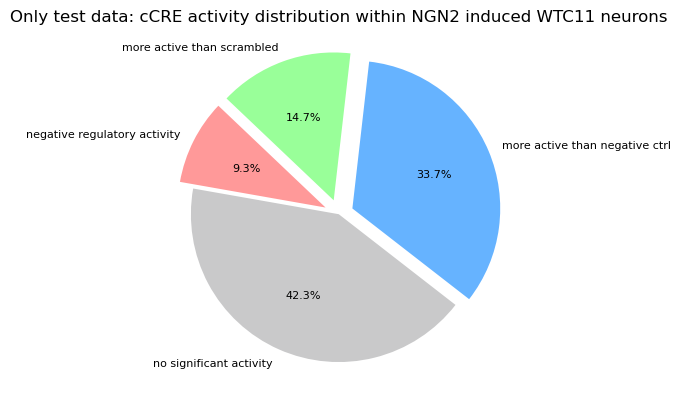

In [80]:
# pie chart for the test data:
test_bins = [1,9]
counts = mpra_80k_ngn2_balanced_chr_binning.loc[mpra_80k_ngn2_balanced_chr_binning['BIN'].isin(test_bins)]["plot_pie_chart_activity_group"].value_counts()

colors = ['#c9c9ca','#66b3ff','#99ff99', '#ff9999']  # Adjust for your group count
explode = [0.1 if val < counts.max() else 0 for val in counts]  # Explode everything except the biggest
counts.plot.pie(
    autopct='%1.1f%%',
    startangle=170,
    ylabel='',
    textprops={'fontsize': 8},
    explode=explode,
    colors=colors,
)
plt.title(f"Only test data: cCRE activity distribution within NGN2 induced WTC11 neurons")

In [50]:
!pwd

/home/kisa/coding/80K_MPRA/80K-Analysis/06_variant_element_analysis/notebooks


In [15]:
mpra_80k_metadata_df_chr_binning_test

,name,sequence,category,class,source,ref,chr,start,end,strand,variant_class,variant_pos,SPDI,allele,info,bcalm_element_adjusted_p_value,bcalm_element_log_ratio_activity,bcalm_data_exists,label,BIN
2287,cardiac_neuro_cava_random:SKI|ENSG00000157933....,AAGAATACAAGTAACTGATGAATGAAGGGGGCATCTTGTGTCCCCA...,element,test,NaN,GRCh38,chr1,2181843.0,2182113.0,+,None,None,None,None,NaN,1.000000e+00,-0.922803,True,cardiac_neuro_cava_random,1
2288,cardiac_neuro_cava_random:SKI|ENSG00000157933....,TTGGGTATGCTGCCCCCCAGCTGGCGGGGCACCGGGGACAGGCACA...,element,test,NaN,GRCh38,chr1,2182439.0,2182709.0,+,None,None,None,None,NaN,6.968128e-11,0.233262,True,cardiac_neuro_cava_random,1
2291,cardiac_neuro_cava_random:SKI|ENSG00000157933....,CCGGAGAGTCTCAGCTCCCGCAGCCCTAACAAACGACCACAGACCT...,element,test,NaN,GRCh38,chr1,2188389.0,2188659.0,+,None,None,None,None,NaN,1.400712e-04,-0.204602,True,cardiac_neuro_cava_random,1
2292,cardiac_neuro_cava_random:SKI|ENSG00000157933....,AGGGTCTTACTCTGTCACCCAGGCTGGAGTGCAGTGGTGCAATCAT...,element,test,NaN,GRCh38,chr1,2192636.0,2192906.0,+,None,None,None,None,NaN,3.601548e-08,-0.045878,True,cardiac_neuro_cava_random,1
2294,cardiac_neuro_cava_random:SKI|ENSG00000157933....,GGCTGCCCTGCCCAGGCCTGGGCACAGCTGCACTGACTGTTCCTGG...,element,test,NaN,GRCh38,chr1,2203380.0,2203650.0,+,None,None,None,None,NaN,1.000000e+00,-1.113699,True,cardiac_neuro_cava_random,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66020,cardiac_neuro_cava_random:ALT_FLT4|ENSG0000003...,ATGTGGGGATAGGCTCGTCAGTTACAATATTGGTGGTGAAGGGAGA...,variant,test,NaN,GRCh38,chr5,180691608.0,180691878.0,-,[SNV],[158],[NC_000005.10:180691719:G:A],[alt],NaN,2.100086e-03,-0.200918,True,cardiac_neuro_cava_random,9
66021,cardiac_neuro_cava_random:ALT_FLT4|ENSG0000003...,ATGTGGGGATAGGCTCGTCAGTTACAATATTGGTGGTGAAGGGAGA...,variant,test,NaN,GRCh38,chr5,180691608.0,180691878.0,-,[SNV],[80],[NC_000005.10:180691797:G:C],[alt],NaN,5.618700e-06,0.098428,True,cardiac_neuro_cava_random,9
66022,cardiac_neuro_cava_random:ALT_FLT4|ENSG0000003...,ATCTGCCACTTTCTCGCAGCCTTGTCCTGGTTTTCTGGGTTAGCCA...,variant,test,NaN,GRCh38,chr5,180693076.0,180693346.0,-,[SNV],[197],[NC_000005.10:180693148:T:C],[alt],NaN,1.030844e-28,0.153789,True,cardiac_neuro_cava_random,9
66023,cardiac_neuro_cava_random:ALT_FLT4|ENSG0000003...,ATCTGCCACTTTCTCGCAGCCTTGTCCTGGTTTTCTGGGTTAGCCA...,variant,test,NaN,GRCh38,chr5,180693076.0,180693346.0,-,[SNV],[154],[NC_000005.10:180693191:G:T],[alt],NaN,4.142627e-21,0.079078,True,cardiac_neuro_cava_random,9


In [ ]:
# https://colab.research.google.com/github/kundajelab/rlsgkm/blob/master/examples/Demo_Regression_on_Simulated_Data.ipynb#scrollTo=ZPaIw8BV0wAM
# https://github.com/kundajelab/lsgkm-svr?tab=readme-ov-file
# https://pmc.ncbi.nlm.nih.gov/articles/PMC4520745/#_ad93_

In [ ]:
!rm -rf lsgkm
!git clone https://github.com/kundajelab/rlsgkm.git
%cd rlsgkm
%cd src
!make
!make install

Cloning into 'rlsgkm'...
remote: Enumerating objects: 106, done.
remote: Counting objects: 100% (106/106), done.
remote: Compressing objects: 100% (94/94), done.
remote: Total 106 (delta 55), reused 34 (delta 11), pack-reused 0 (from 0)
Receiving objects: 100% (106/106), 154.47 KiB | 1.23 MiB/s, done.
Resolving deltas: 100% (55/55), done.
/home/kisa/coding/80K_MPRA/80K-Analysis/06_variant_element_analysis/notebooks/rlsgkm
/home/kisa/coding/80K_MPRA/80K-Analysis/06_variant_element_analysis/notebooks/rlsgkm/src
g++ -Wall -Wconversion -O3 -fPIC -c libsvm.cpp
g++ -Wall -Wconversion -O3 -fPIC -c libsvm_gkm.c
g++ -Wall -Wconversion -O3 -fPIC gkmtrain.c libsvm.o libsvm_gkm.o -o gkmtrain -lm -lpthread
g++ -Wall -Wconversion -O3 -fPIC gkmpredict.c libsvm.o libsvm_gkm.o -o gkmpredict -lm -lpthread
g++ -Wall -Wconversion -O3 -fPIC gkmexplain.c libsvm.o libsvm_gkm.o -o gkmexplain -lm -lpthread
cp gkmtrain gkmpredict gkmexplain ../bin
[Errno 2] No such file or directory: '/content'
/home/kisa/codin

In [2]:
!pwd

/home/kisa/coding/80K_MPRA/80K-Analysis/06_variant_element_analysis/notebooks/rlsgkm/src


In [2]:
#Grab some simulated data from another project

!wget https://raw.githubusercontent.com/kundajelab/feature_interactions/8f97332/data/train_neg_labels.txt.gz -O train_labels.txt.gz
!wget https://raw.githubusercontent.com/kundajelab/feature_interactions/8f97332/data/train_simulation.simdata.gz -O train_simulation.simdata.gz
!wget https://raw.githubusercontent.com/kundajelab/feature_interactions/8f97332/data/test_neg_labels.txt.gz -O test_labels.txt.gz
!wget https://raw.githubusercontent.com/kundajelab/feature_interactions/8f97332/data/test_simulation.simdata.gz -O test_simulation.simdata.gz

--2025-04-04 18:22:55--  https://raw.githubusercontent.com/kundajelab/feature_interactions/8f97332/data/train_neg_labels.txt.gz
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 523531 (511K) [application/octet-stream]
Saving to: ‘train_labels.txt.gz’

train_labels.txt.gz 100%[===================>] 511.26K  --.-KB/s    in 0.03s   

2025-04-04 18:22:55 (14.6 MB/s) - ‘train_labels.txt.gz’ saved [523531/523531]

--2025-04-04 18:22:55--  https://raw.githubusercontent.com/kundajelab/feature_interactions/8f97332/data/train_simulation.simdata.gz
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.


In [3]:
!gunzip -f *.gz

In [4]:
def simdata_to_fasta(simdata_file, fa_file):
  with open(fa_file, 'w') as outf:
    for i, line in enumerate(open(simdata_file)):
      if i > 0:
        id, seq, _, _, _, _ = line.rstrip().split("\t")
        outf.write(">"+id+"\n")
        outf.write(seq+"\n")
  outf.close()

#prepare the fasta files for training/prediction
simdata_to_fasta("train_simulation.simdata", "train_simulation.fa")
simdata_to_fasta("test_simulation.simdata", "test_simulation.fa")

#For speed, only train on 5000 regions and test on 1000
!head -10000 train_simulation.fa > trimmed_train_simulation.fa
!head -2000 test_simulation.fa > trimmed_test_simulation.fa

#My label file had two columns - one for the label without noise and
# the other for the label with noise. I'll take the label with noise
# for training purposes.
#Also take the square root as that is a variance stabilizing transform for counts.
!perl -lane 'print sqrt($F[1])' train_labels.txt | head -5000 > nonoise_train_labels.txt
!perl -lane 'print sqrt($F[1])' test_labels.txt | head -1000 > nonoise_test_labels.txt

In [6]:
!head -4 trimmed_train_simulation.fa

>trainsim-synth0
AGCTTCCTTTCGGGCGGATTCGACTGCTCGTCTAGGATCTAAAGGGAGCGAGGAGTTTTTCGCACACTAATGCAATCGACCGTGGATTGCAGGTCGGTAG
>trainsim-synth1
TGTAAGATCACTTACATGGTTGCACGAACGTCAATACGATTGACGAGCTGAATTTTGGAGTTTTGCTTGCCTATCTTGGCTGCACTCCGAATACGATTTT


In [7]:
#View labels file as a sanity check
!head nonoise_train_labels.txt

1.98888698355797
0.933996430516065
12.8789085363317
9.10575581881588
10.1229327709908
10.6211808979363
0.500560698879818
10.6358666611701
15.3549273800663
10.9921140650608


In [24]:
%cd ../../

/home/kisa/coding/80K_MPRA/80K-Analysis/06_variant_element_analysis/notebooks


In [86]:
#train the regression model
#-y 3 selects regression (default of -y 0 does classification)
#-t controls the choice of kernel. -t 2 (instead of the default of 4)
# avoids upweighting the central positions.
#The parameter -p controls the “epsilon” used in the support vector
# regression objective (i.e. the tolerated margin of error).
# HEADS UP: don’t confuse this with the -e parameter, which determines
# the epsilon used for the convergence criterion (they are both
# called ‘epsilon’, sigh).
#Depending on the problem, the -c parameter (controlling the cost of
# misprediction) will likely have to be adjusted, i.e. the defaults may
# not work out-of-the-box.
# !rlsgkm/bin/gkmtrain -T 16 -y 3 -t 2 -c 10 -p 0.3 trimmed_train_simulation.fa nonoise_train_labels.txt regression
# !rlsgkm/bin/gkmtrain -T 16 -y 3 -t 2 -c 10 -p 0.3 /home/kisa/coding/80K_MPRA/80K-Analysis/06_variant_element_analysis/notebooks/rlsgkm/src/gkm_svm_ttraining.fa /home/kisa/coding/80K_MPRA/80K-Analysis/06_variant_element_analysis/notebooks/rlsgkm/src/gkm_svm_training_label.tsv regression
# !rlsgkm/bin/gkmtrain -T 16 -y 3 -t 2 -c 10 -p 0.3 /home/kisa/coding/80K_MPRA/80K-Analysis/06_variant_element_analysis/notebooks/gkm_svm_training_removed_no_activity.fa /home/kisa/coding/80K_MPRA/80K-Analysis/06_variant_element_analysis/notebooks/gkm_svm_removed_no_activity_training_label.tsv regression_removed_no_activity
!rlsgkm/bin/gkmtrain -T 16 -y 3 -t 2 -c 10 -p 0.3 /home/kisa/coding/80K_MPRA/element_variant_analysis_output/gkm_SVM/downsample_without_activity_sequences_n_19k/gkm_svm_train.fa /home/kisa/coding/80K_MPRA/element_variant_analysis_output/gkm_SVM/downsample_without_activity_sequences_n_19k/gkm_svm_training_label.tsv regression_downsampled_without_activity

INFO 2025-04-24 12:02:06: Number of threads is set to 16
INFO 2025-04-24 12:02:06: Arguments:
INFO 2025-04-24 12:02:06:   file1 = /home/kisa/coding/80K_MPRA/element_variant_analysis_output/gkm_SVM/downsample_without_activity_sequences_n_19k/gkm_svm_train.fa
INFO 2025-04-24 12:02:06:   file2 = /home/kisa/coding/80K_MPRA/element_variant_analysis_output/gkm_SVM/downsample_without_activity_sequences_n_19k/gkm_svm_training_label.tsv
INFO 2025-04-24 12:02:06:   outprefix = regression_downsampled_without_activity
INFO 2025-04-24 12:02:06: Parameters:
INFO 2025-04-24 12:02:06:   svm-type = 3
INFO 2025-04-24 12:02:06:   kernel-type = 2
INFO 2025-04-24 12:02:06:   L = 11
INFO 2025-04-24 12:02:06:   k = 7
INFO 2025-04-24 12:02:06:   d = 3
INFO 2025-04-24 12:02:06:   C = 10
INFO 2025-04-24 12:02:06:   eps (convergence) = 0.001
INFO 2025-04-24 12:02:06:   p (SVR epsilon) = 0.3
INFO 2025-04-24 12:02:06:   shrinking = no
INFO 2025-04-24 12:02:06: reading... 0
INFO 2025-04-24 12:02:06: reading... 1000

In [55]:
#make predictions on the test set
# !rlsgkm/bin/gkmpredict -T 16 trimmed_test_simulation.fa regression.model.txt regression_test_preds.txt
# !rlsgkm/bin/gkmpredict -T 16 /home/kisa/coding/80K_MPRA/80K-Analysis/06_variant_element_analysis/notebooks/rlsgkm/src/gkm_svm_test.fa regression.model.txt regression_test_preds.txt
!rlsgkm/bin/gkmpredict -T 16 /home/kisa/coding/80K_MPRA/80K-Analysis/06_variant_element_analysis/notebooks/gkm_svm_test_removed_no_activity.fa regression_removed_no_activity.model.txt regression_test_preds_no_activity.txt

INFO 2025-04-06 22:48:34: Number of threads is set to 16
INFO 2025-04-06 22:48:34: load model regression_removed_no_activity.model.txt
INFO 2025-04-06 22:48:34: reading... 1000/8351
INFO 2025-04-06 22:48:35: reading... 2000/8351
INFO 2025-04-06 22:48:36: reading... 3000/8351
INFO 2025-04-06 22:48:36: reading... 4000/8351
INFO 2025-04-06 22:48:37: reading... 5000/8351
INFO 2025-04-06 22:48:37: reading... 6000/8351
INFO 2025-04-06 22:48:38: reading... 7000/8351
INFO 2025-04-06 22:48:39: reading... 8000/8351
INFO 2025-04-06 22:48:39: write prediction result to regression_test_preds_no_activity.txt
INFO 2025-04-06 22:48:41: 100 scored
INFO 2025-04-06 22:48:44: 200 scored
INFO 2025-04-06 22:48:47: 300 scored
INFO 2025-04-06 22:48:50: 400 scored
INFO 2025-04-06 22:48:52: 500 scored
INFO 2025-04-06 22:48:55: 600 scored
INFO 2025-04-06 22:48:58: 700 scored
INFO 2025-04-06 22:49:00: 800 scored
INFO 2025-04-06 22:49:03: 900 scored
INFO 2025-04-06 22:49:06: 1000 scored
INFO 2025-04-06 22:49:09: 1

In [87]:
!rlsgkm/bin/gkmpredict -T 16 /home/kisa/coding/80K_MPRA/element_variant_analysis_output/gkm_SVM/downsample_without_activity_sequences_n_19k/gkm_svm_test.fa regression_downsampled_without_activity.model.txt regression_test_preds_downsampled_without_activity.txt

INFO 2025-04-24 12:14:41: Number of threads is set to 16
INFO 2025-04-24 12:14:41: load model regression_downsampled_without_activity.model.txt
INFO 2025-04-24 12:14:42: reading... 1000/5002
INFO 2025-04-24 12:14:43: reading... 2000/5002
INFO 2025-04-24 12:14:44: reading... 3000/5002
INFO 2025-04-24 12:14:45: reading... 4000/5002
INFO 2025-04-24 12:14:45: reading... 5000/5002
INFO 2025-04-24 12:14:45: write prediction result to regression_test_preds_downsampled_without_activity.txt
INFO 2025-04-24 12:14:48: 100 scored
INFO 2025-04-24 12:14:50: 200 scored
INFO 2025-04-24 12:14:52: 300 scored
INFO 2025-04-24 12:14:55: 400 scored
INFO 2025-04-24 12:14:57: 500 scored
INFO 2025-04-24 12:15:00: 600 scored
INFO 2025-04-24 12:15:03: 700 scored
INFO 2025-04-24 12:15:05: 800 scored
INFO 2025-04-24 12:15:07: 900 scored
INFO 2025-04-24 12:15:09: 1000 scored
INFO 2025-04-24 12:15:12: 1100 scored
INFO 2025-04-24 12:15:14: 1200 scored
INFO 2025-04-24 12:15:16: 1300 scored
INFO 2025-04-24 12:15:19: 14

In [105]:
#plot the labels vs preds.
def plot_gkm_svm_regression_results(test_prediction_path, test_label_path):
    preds = np.array([float(x.rstrip().split("\t")[-1])
                  for x in open(test_prediction_path)])
    labels = np.array([float(x.rstrip().split("\t")[-1])
                  for x in open(test_label_path)])
    plt.scatter(labels, preds)
    # Add line y = x from -1 to 1.5
    x_line = np.linspace(-1, 1.5, 100)
    plt.plot(x_line, x_line, color='black', linestyle='--', label='y = x')
    # compute correlation between the predictions and the labels

    plt.xlabel("Measured")
    plt.ylabel("Predicted")
    plt.show()

from scipy.stats import pearsonr, spearmanr

def plot_gkm_svm_correlation(test_prediction_path, test_label_path):
    preds = np.array([float(x.rstrip().split("\t")[-1])
                  for x in open(test_prediction_path)])
    labels = np.array([float(x.rstrip().split("\t")[-1])
                  for x in open(test_label_path)])
    # Compute correlations
    pearson_r, pearson_p = pearsonr(labels, preds)
    spearman_r, spearman_p = spearmanr(labels, preds)

    # Plot
    plt.figure(figsize=(6, 6))
    plt.scatter(labels, preds, alpha=0.5, edgecolors='k')
    # plt.plot(labels, labels, color="black")
    # Add line y = x from -1 to 1.5
    x_line = np.linspace(-1, 1.5, 100)
    plt.plot(x_line, x_line, color='black', linestyle='--', label='y = x')
    plt.xlabel("True Labels")
    plt.ylabel("Predictions")
    plt.title(f"Pearson r = {pearson_r:.3f} (p = {pearson_p:.2e})\n"
            f"Spearman ρ = {spearman_r:.3f} (p = {spearman_p:.2e})")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

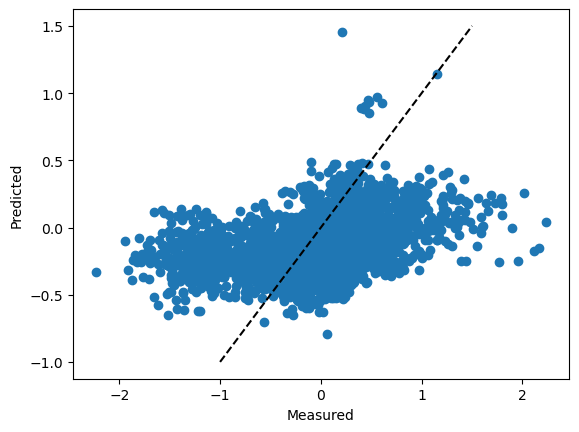

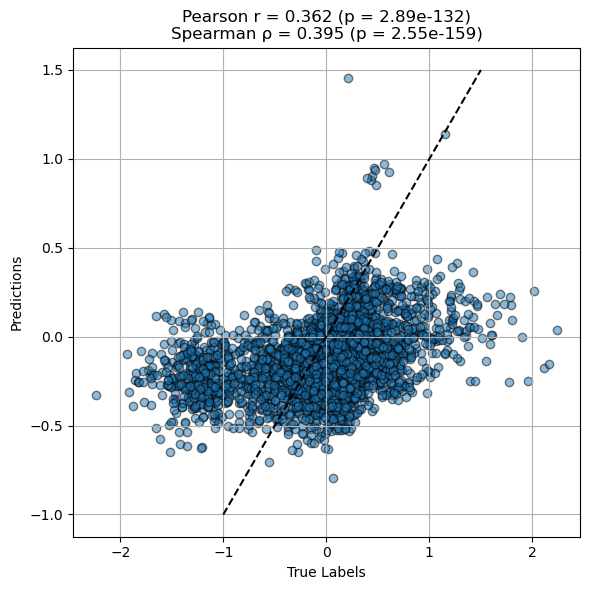

In [ ]:
test_predictions = "/home/kisa/coding/80K_MPRA/80K-Analysis/06_variant_element_analysis/notebooks/regression_test_preds_downsampled_without_activity.txt"
test_labels = "/home/kisa/coding/80K_MPRA/element_variant_analysis_output/gkm_SVM/downsample_without_activity_sequences_n_19k/gkm_svm_test_label.tsv"
plot_gkm_svm_regression_results(test_prediction_path=test_predictions, test_label_path=test_labels)
plot_gkm_svm_correlation(test_prediction_path=test_predictions, test_label_path=test_labels)


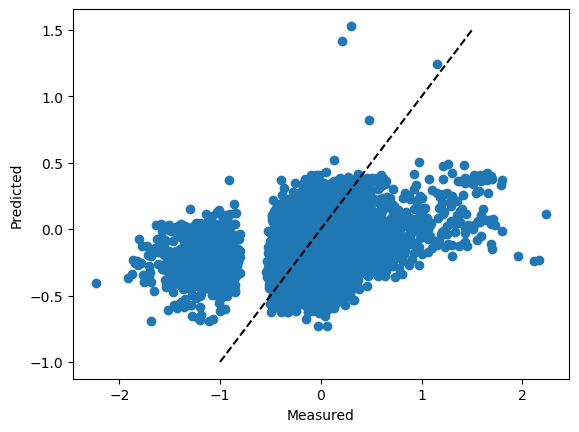

In [107]:
#plot the labels vs preds.
import numpy as np
from matplotlib import pyplot as plt

preds = np.array([float(x.rstrip().split("\t")[-1])
                  for x in open("regression_test_preds.txt")])
labels = np.array([float(x.rstrip().split("\t")[-1])
                  for x in open("/home/kisa/coding/80K_MPRA/80K-Analysis/06_variant_element_analysis/notebooks/rlsgkm/src/gkm_svm_test_label.tsv")])
preds = np.array([float(x.rstrip().split("\t")[-1])
                  for x in open("regression_test_preds_no_activity.txt")])
labels = np.array([float(x.rstrip().split("\t")[-1])
                  for x in open("/home/kisa/coding/80K_MPRA/80K-Analysis/06_variant_element_analysis/notebooks/gkm_svm_test_removed_no_activity_label.tsv")])

plt.scatter(labels, preds)
# Add line y = x from -1 to 1.5
x_line = np.linspace(-1, 1.5, 100)
plt.plot(x_line, x_line, color='black', linestyle='--', label='y = x')
# compute correlation between the predictions and the labels

plt.xlabel("Measured")
plt.ylabel("Predicted")
plt.show()

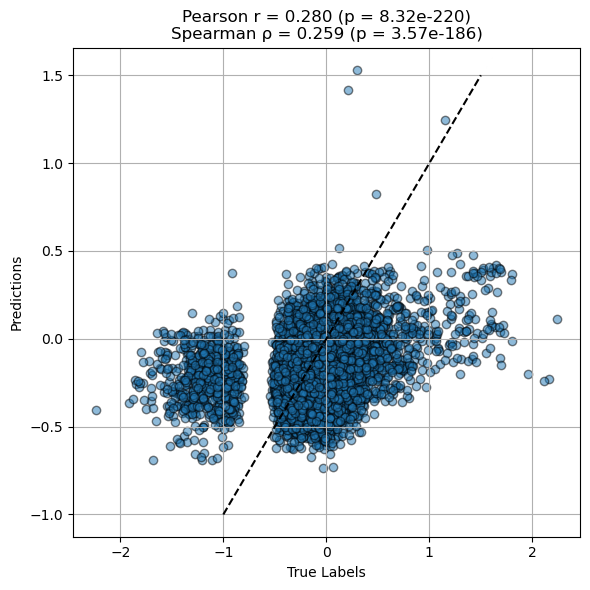

In [108]:
from scipy.stats import pearsonr, spearmanr
# Compute correlations
pearson_r, pearson_p = pearsonr(labels, preds)
spearman_r, spearman_p = spearmanr(labels, preds)

# Plot
plt.figure(figsize=(6, 6))
plt.scatter(labels, preds, alpha=0.5, edgecolors='k')
# plt.plot(labels, labels, color="black")
# Add line y = x from -1 to 1.5
x_line = np.linspace(-1, 1.5, 100)
plt.plot(x_line, x_line, color='black', linestyle='--', label='y = x')
plt.xlabel("True Labels")
plt.ylabel("Predictions")
plt.title(f"Pearson r = {pearson_r:.3f} (p = {pearson_p:.2e})\n"
        f"Spearman ρ = {spearman_r:.3f} (p = {spearman_p:.2e})")
plt.grid(True)
plt.tight_layout()
plt.show()

In [109]:
#Compute gkmexplain importance scores on a handful of regions
# !head -20 trimmed_test_simulation.fa > toexplain_test_simulation.fa
# !rlsgkm/bin/gkmexplain toexplain_test_simulation.fa regression.model.txt imp_toexplain_test_simulation.txt
# !head -20 /home/kisa/coding/80K_MPRA/80K-Analysis/06_variant_element_analysis/notebooks/gkm_svm_test_removed_no_activity.fa > /home/kisa/coding/80K_MPRA/80K-Analysis/06_variant_element_analysis/notebooks/example_gkm_svm_test_removed_no_activity.fa
# !rlsgkm/bin/gkmexplain /home/kisa/coding/80K_MPRA/80K-Analysis/06_variant_element_analysis/notebooks/example_gkm_svm_test_removed_no_activity.fa regression_removed_no_activity.model.txt imp_toexplain_test_subset_removed_no_activity_simulation.txt
!rlsgkm/bin/gkmexplain /home/kisa/coding/80K_MPRA/element_variant_analysis_output/gkm_SVM/downsample_without_activity_sequences_n_19k/gkm_svm_test.fa regression_downsampled_without_activity.model.txt interpret_test_subset_downsampled_without_activity.txt

INFO 2025-04-24 16:13:08: Number of threads is set to 1
INFO 2025-04-24 16:13:08: load model regression_downsampled_without_activity.model.txt
INFO 2025-04-24 16:13:08: reading... 1000/5002
INFO 2025-04-24 16:13:09: reading... 2000/5002
INFO 2025-04-24 16:13:09: reading... 3000/5002
INFO 2025-04-24 16:13:10: reading... 4000/5002
INFO 2025-04-24 16:13:10: reading... 5000/5002
INFO 2025-04-24 16:13:10: write prediction result to interpret_test_subset_downsampled_without_activity.txt
INFO 2025-04-24 16:13:56: 100 scored
INFO 2025-04-24 16:14:44: 200 scored
INFO 2025-04-24 16:15:36: 300 scored
INFO 2025-04-24 16:16:31: 400 scored
INFO 2025-04-24 16:17:27: 500 scored
INFO 2025-04-24 16:18:31: 600 scored
INFO 2025-04-24 16:19:24: 700 scored
INFO 2025-04-24 16:20:18: 800 scored
INFO 2025-04-24 16:21:05: 900 scored
INFO 2025-04-24 16:21:57: 1000 scored
INFO 2025-04-24 16:22:45: 1100 scored
INFO 2025-04-24 16:23:32: 1200 scored
INFO 2025-04-24 16:24:18: 1300 scored
INFO 2025-04-24 16:25:04: 140

In [112]:
#read in the importance scores
# impscores = [
#     np.array( [[float(z) for z in y.split(",")] for y in x.rstrip().split("\t")[2].split(";")])
#     for x in open("imp_toexplain_test_simulation.txt")
# ]
#read in the importance scores
# impscores = [
#     np.array( [[float(z) for z in y.split(",")] for y in x.rstrip().split("\t")[2].split(";")])
#     for x in open("imp_toexplain_test_subset_removed_no_activity_simulation.txt")
# ]
impscores = [
    np.array( [[float(z) for z in y.split(",")] for y in x.rstrip().split("\t")[2].split(";")])
    for x in open("interpret_test_subset_downsampled_without_activity.txt")
]

In [60]:
!pip install vizsequence

  Preparing metadata (setup.py) ... done
  Created wheel for vizsequence: filename=vizsequence-0.1.1.0-py3-none-any.whl size=3225 sha256=528b25bfa550d33732f1eac4d2467b9b0482e8777a8e4d4f94146a80621f93c5
  Stored in directory: /home/kisa/.cache/pip/wheels/84/ec/de/d49ee236017a70922cd959b576b597ac47b2a35a20706e06fe
Successfully built vizsequence


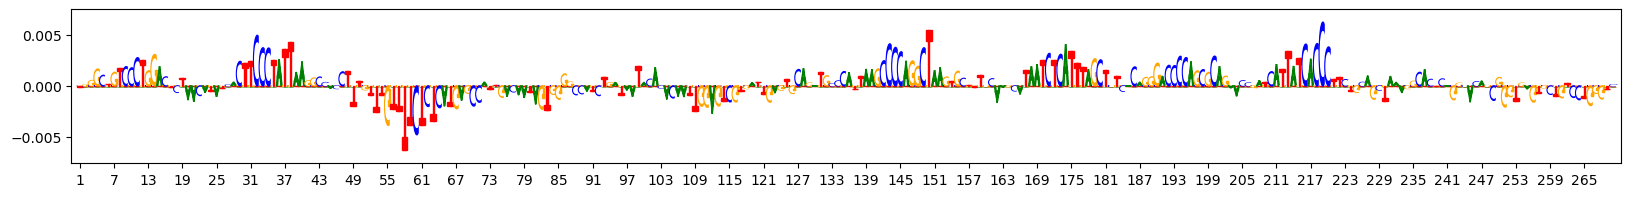

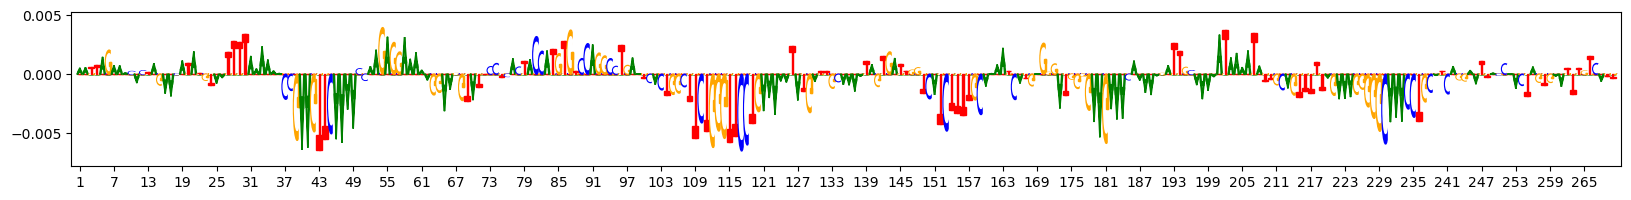

In [113]:
#visualize importance scores on a couple of sequences, as a sanity check
import vizsequence
vizsequence.viz_sequence.plot_weights(impscores[2])
vizsequence.viz_sequence.plot_weights(impscores[3])

#### Compute importance scores:

In [ ]:
# get importance scores using gkmexplain: https://github.com/kundajelab/gkmexplain/blob/master/lsgkmexplain_Nanog.ipynb

##### Generate dinuc shuffled sequences for computing null distribution of importance scores

In [132]:
# !pip install deeplift
from deeplift.dinuc_shuffle import dinuc_shuffle

import numpy as np
import random
np.random.seed(1234)
random.seed(1234)

num_dinuc_shuffled_seqs = 500
#Generate the dinucleotide shuffled sequences and write to a file
fasta_seqs_no_N = [x.rstrip() for (i,x) in enumerate(open("/home/kisa/coding/80K_MPRA/element_variant_analysis_output/gkm_SVM/downsample_without_activity_sequences_n_19k/gkm_svm_test.fa"))
                   if (i%2==1 and ('N' not in x))]

fasta_seqs_no_N
open("gkm_svm_dnshuff_seqs.fa", 'w').write(
    "\n".join(
        [">seq"+str(i)+"\n"+ dinuc_shuffle(str(np.random.choice(fasta_seqs_no_N)))
            for i in range(num_dinuc_shuffled_seqs)]))

139389

In [121]:
len(fasta_seqs_no_N)

4259

In [131]:
counter = 0
for elem in fasta_seqs_no_N:
    if isinstance(elem, str):
        chosen_seq = np.random.choice(fasta_seqs_no_N)
        print(chosen_seq)
        print(type(str(chosen_seq)))
        dinuc_shuffle(chosen_seq)
        break
        counter += 1

counter

GATAGTATCATGTGTGTTTTATGCTTGGCCTCTGAAAGCAGACTGGCTGGGTTCAAAGTCCTGTCTCTGCCACTCGGTGGCTGTGTTACTTCTCCCAGCCTCAGCATCTTTATCTATAAAATGAGGATAATAATAGCACTAGCCTCATGAGATGGTTATGAGGCTTAAATGAGATAATGCTTATAATGTGCTTGACCTCAGGACCAAGCAAGCACTGAGGTGCCTCTGCTGTCATTATCTACACAAAGCATGTAACCAGGGCTGACTCAG
<class 'str'>


ValueError: Expected string or one-hot encoded array

In [117]:
np.random.choice(fasta_seqs_no_N)

'TGTCCTGTCTCTAATAATTGCTGAAAACTCAAAGAGGTAGATAAATAAGCCTCCTTGGGATCAATAGCAGAAGGAACTCCAAGGCTGATGGTAAAGCTTCGTAAGGATGATGCCGAAAGGGAACTGGGGTCTCCATGGTGATAAGAGGCTGGGGACCAATGAGAGCTGAAGGCGGAGCAGGACTTGCGGGGAAGACTCATGGGAGTTGGGAGTCATTTAACTATTTGTTTGCTTCTTGAAAATTTAGACACCAGCTGTAACTACATTGCA'

##### Compute importance scores and hypothetical importance scores


In [ ]:
! [[ -e gkmexplain_positives_impscores.txt ]]  || lsgkm/src/gkmexplain gkm_svm_test.fa regression_downsampled_without_activity.model.txt gkmexplain_positives_impscores.txt
! [[ -e gkmexplain_positives_hypimpscores.txt ]] || lsgkm/src/gkmexplain -m 1 gkm_svm_test.fa regression_downsampled_without_activity.model.txt gkmexplain_positives_hypimpscores.txt
! [[ -e gkmexplain_dnshuff_impscores.txt ]] || lsgkm/src/gkmexplain gkm_svm_dnshuff_seqs.fa regression_downsampled_without_activity.model.txt gkmexplain_dnshuff_impscores.txt

#### Use tfmodisco-lite

In [ ]:
modisco motifs -s ../bpnet/ohe.npz -a ../bpnet/attr.npz -n 2000 -o modisco_results.h5